# Slide figures: motion scrubbing sensitivity tool
Builds the 10 slide figures (16:9 PNG, 2000×1125 px) in `scrubbing_figures/`, in presentation order. All the figure code is in this notebook: **Run All** to rebuild every slide (about a minute; slide 08 is the slowest, because it costs every combination of lost pairs).

* **Settings** are in the next cell: the example protocols, motion flags, CBF range, the +15% SD threshold and the 25% limit. The CBF/ATT cost itself comes from `oxasl_optpcasl.scrub` and is averaged over ATT 0.5–2.5 s (`DEFAULT_ATT_RANGE`). Where a scrubbing pattern leaves an ATT inestimable, a Gaussian ATT prior (`ATT_PRIOR`, 1.3 ± 1.0 s) is used there, so CBF keeps a finite cost.
* **Slide code:** each slide has its own cell, with a short note for presenting it. Run a slide's cell to rebuild just that slide after editing it.

## Setup and settings

In [1]:
import os
import matplotlib.pyplot as plt
from IPython.display import Image, display
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch, Rectangle
import oxasl_optpcasl as opt
from oxasl_optpcasl.scrub import DEFAULT_ATT_RANGE, ScrubbingAnalysis, group_pairs
OUT = "scrubbing_figures"   # output folder for the PNGs
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, LIGHT = "#0b0b0b", "#52514e", "#a3a29d", "#e4e3df"
SCRUB, KEEP, CLEAN = BLUE, ORANGE, "#d6d5d0"
plt.rcParams.update({
    "font.size": 15, "axes.titlesize": 18, "axes.labelsize": 15, "figure.dpi": 150,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": LIGHT, "grid.linewidth": 0.8, "axes.edgecolor": "#8a8984",
    "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False, "lines.linewidth": 2.5,
    "savefig.facecolor": "white", "axes.axisbelow": True,
})
SLIDE = (13.33, 7.5)
CBF_VALUES = [10, 20, 35, 50, 65, 80, 100]
MAX_SD_INCREASE = {"CBF": 0.15, "ATT": 0.15}
MAX_LOSS = 0.25
ATT_PRIOR = (1.3, 1.0)   # Gaussian ATT prior (mean, SD, s), used wherever ATT becomes inestimable
FIVE = [1.025, 1.525, 2.025, 2.525, 3.025]
SCENARIOS = {
    "16-pair": dict(title="16-pair protocol (1 repeat each)",
                    plds=[0.0] * 8 + [0.2, 0.5, 0.8, 1.1, 1.4, 1.7, 2.0, 2.2],
                    taus=[0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8] + [1.8] * 8,
                    flagged=[3, 10, 12], motion=[0.8, 1.5, 0.6]),
    "5x1": dict(title="5-PLD, 1 repeat each", plds=FIVE, taus=[1.8] * 5,
                flagged=[0, 2], motion=[1.2, 0.7]),
    "5x2": dict(title="5-PLD, 2 repeats each", plds=FIVE * 2, taus=[1.8] * 10,
                flagged=[0, 2], motion=[1.2, 0.7]),
}
for sc in SCENARIOS.values():
    lds, plds, repeats, delay_of_pair = group_pairs(sc["plds"], sc["taus"])
    sa = ScrubbingAnalysis(lds, plds, repeats, delay_of_pair=delay_of_pair, cbf_values=CBF_VALUES, att_prior=ATT_PRIOR)
    removed, retained = sa.select_pairs(sc["flagged"], MAX_SD_INCREASE, MAX_LOSS, sc["motion"])
    sc.update(sa=sa, removed=removed, retained=retained, counts=sa.counts(removed))


def fmt(v):
    return "∞" if not np.isfinite(v) else f"+{100 * v:.1f}%"


def prior_note(sa, counts):
    """'prior for ATT a–b s' if the ATT prior is needed for this scrubbing pattern, else ''"""
    first, last = sa.prior_range(counts)
    return "" if not np.isfinite(first) else f"prior for ATT {first:.2f}–{last:.2f} s"


PRIOR_TEXT = f"Gaussian ATT prior ({ATT_PRIOR[0]:g} ± {ATT_PRIOR[1]:g} s)"


def save(fig, name):
    os.makedirs(OUT, exist_ok=True)
    fig.savefig(os.path.join(OUT, name), dpi=150)
    plt.close(fig)
    print("wrote", os.path.join(OUT, name))
    return os.path.join(OUT, name)


def show(path):
    """Display a saved slide in the notebook"""
    display(Image(filename=path, width=1000))

### Scrubbing decisions behind the example slides
The gate's decision for each example protocol, for reference when presenting slides 05–07.

In [2]:
import pandas as pd

rows = []
for key, sc in SCENARIOS.items():
    sa, counts = sc["sa"], sc["counts"]
    rows.append({"protocol": sc["title"], "flagged pairs": sc["flagged"], "scrubbed": sc["removed"],
                 "kept (too costly)": sc["retained"], "data removed": f"{1 - counts.sum() / sa.npairs:.0%}",
                 "CBF SD": f"{sa.sd_increase(counts, 'CBF'):+.1%}", "ATT SD": f"{sa.sd_increase(counts, 'ATT'):+.1%}"})
pd.DataFrame(rows).set_index("protocol")

,flagged pairs,scrubbed,kept (too costly),data removed,CBF SD,ATT SD
protocol,,,,,,
16-pair protocol (1 repeat each),"[3, 10, 12]","[3, 12]",[10],12%,+1.8%,+2.5%
"5-PLD, 1 repeat each","[0, 2]",[],"[0, 2]",0%,+0.0%,+0.0%
"5-PLD, 2 repeats each","[0, 2]",[0],[2],10%,+0.8%,+14.6%


## 01 · How the tool works
The pipeline in five steps, with a small example under each: protocol → kinetic-model sensitivity of each pair → information summed over the pairs kept → best achievable SD of CBF and ATT (CRLB) → decision against the limits.

wrote scrubbing_figures/01_how_it_works.png


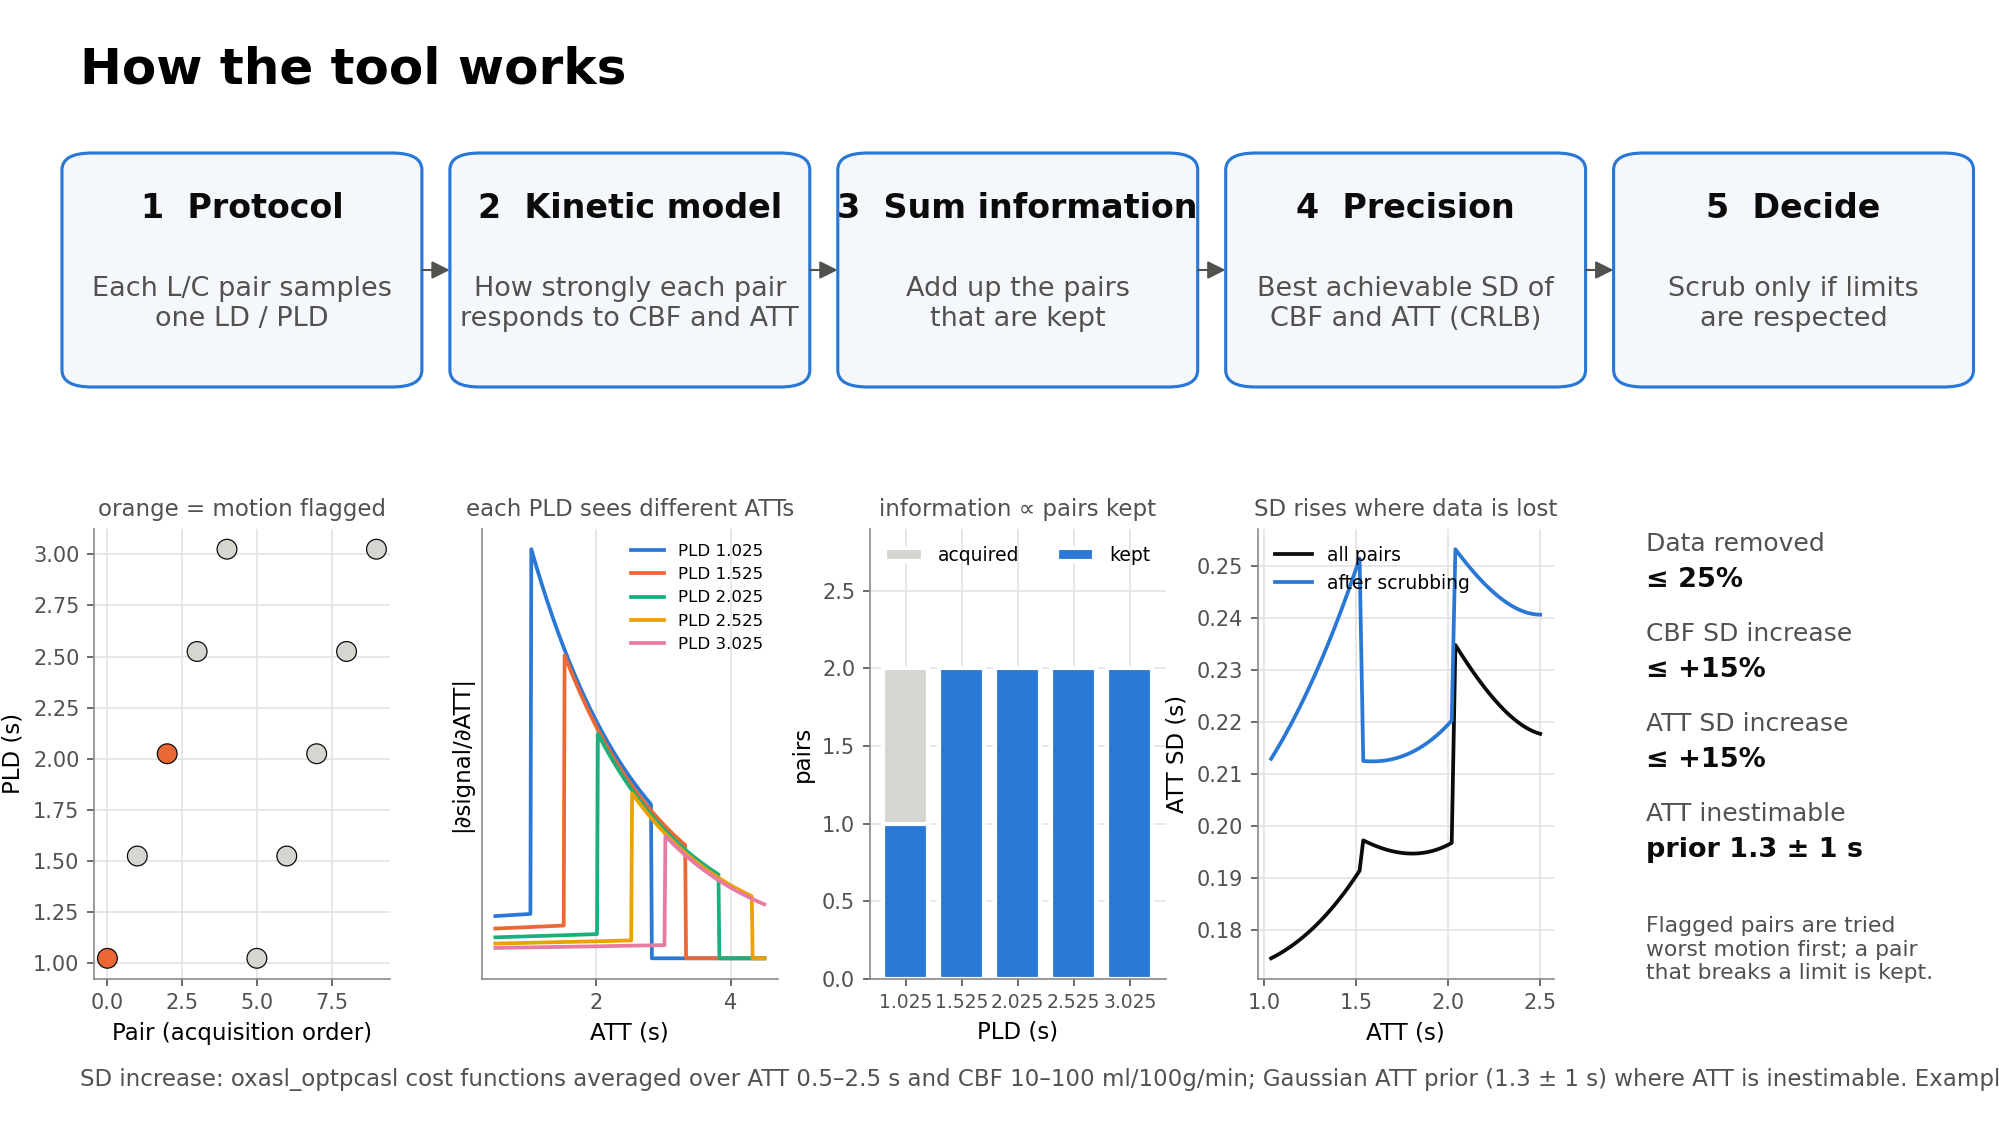

In [3]:
def fig_how_it_works():
    sc = SCENARIOS["5x2"]
    sa = sc["sa"]
    fig = plt.figure(figsize=SLIDE)
    fig.suptitle("How the tool works", x=0.04, ha="left", fontsize=24, fontweight="bold", y=0.96)
    steps = [
        ("1  Protocol", "Each L/C pair samples\none LD / PLD"),
        ("2  Kinetic model", "How strongly each pair\nresponds to CBF and ATT"),
        ("3  Sum information", "Add up the pairs\nthat are kept"),
        ("4  Precision", "Best achievable SD of\nCBF and ATT (CRLB)"),
        ("5  Decide", "Scrub only if limits\nare respected"),
    ]
    w, gap, x0, y0, h = 0.172, 0.022, 0.035, 0.66, 0.2
    for i, (head, body) in enumerate(steps):
        x = x0 + i * (w + gap)
        fig.patches.append(FancyBboxPatch((x, y0), w, h, boxstyle="round,pad=0.004,rounding_size=0.015",
                                          transform=fig.transFigure, fc="#f4f8fd", ec=BLUE, lw=1.5))
        fig.text(x + w / 2, y0 + h - 0.045, head, ha="center", va="center", fontsize=16, fontweight="bold", color=INK)
        fig.text(x + w / 2, y0 + 0.07, body, ha="center", va="center", fontsize=13, color=INK2)
        if i < len(steps) - 1:
            fig.patches.append(FancyArrowPatch((x + w + 0.002, y0 + h / 2), (x + w + gap - 0.002, y0 + h / 2),
                                               transform=fig.transFigure, arrowstyle="-|>", mutation_scale=18, color=INK2))

    axes = [fig.add_axes([x0 + i * (w + gap) + 0.012, 0.13, w - 0.024, 0.4]) for i in range(5)]
    for ax in axes:
        ax.tick_params(labelsize=10)

    # 1: pairs in acquisition order
    ax = axes[0]
    colors = [KEEP if p in sc["flagged"] else CLEAN for p in range(sa.npairs)]
    ax.scatter(np.arange(sa.npairs), sa.plds[sa.delay_of_pair], s=90, c=colors, edgecolor=INK, lw=0.6, zorder=3)
    ax.set_xlabel("Pair (acquisition order)", fontsize=11); ax.set_ylabel("PLD (s)", fontsize=11)
    ax.set_title("orange = motion flagged", fontsize=11, color=INK2)

    # 2: sensitivity to ATT for each delay
    ax = axes[1]
    att = np.linspace(0.5, 4.5, 300)
    model = sa.protocols[3].kinetic_model
    for i, (ld, pld) in enumerate(zip(sa.lds, sa.plds)):
        df, datt = model.sensitivity(np.array([ld]), np.array([ld + pld]), att)
        ax.plot(att, np.abs(datt[0]) * 1e3, lw=1.8, color=[BLUE, ORANGE, AQUA, "#eda100", "#e87ba4"][i],
                label=f"PLD {pld:g}")
    ax.set_xlabel("ATT (s)", fontsize=11); ax.set_ylabel("|∂signal/∂ATT|", fontsize=11); ax.set_yticks([])
    ax.legend(fontsize=8, loc="upper right"); ax.set_title("each PLD sees different ATTs", fontsize=11, color=INK2)

    # 3: information per delay, before and after scrubbing
    ax = axes[2]
    x = np.arange(sa.ndelays)
    ax.bar(x, sa.repeats, color=CLEAN, edgecolor="white", lw=2, label="acquired")
    ax.bar(x, sc["counts"], color=BLUE, edgecolor="white", lw=2, label="kept")
    ax.set_xticks(x, [f"{p:g}" for p in sa.plds], fontsize=9)
    ax.set_xlabel("PLD (s)", fontsize=11); ax.set_ylabel("pairs", fontsize=11)
    ax.set_ylim(0, sa.repeats.max() * 1.45)
    ax.legend(fontsize=9, loc="upper center", ncol=2); ax.set_title("information ∝ pairs kept", fontsize=11, color=INK2)

    # 4: SD vs ATT
    ax = axes[3]
    atts = sa.att_dist.atts
    full = sa.sd_by_att(sa.repeats)[1][3]
    scr = sa.sd_by_att(sc["counts"])[1][3]
    ax.plot(atts, full, color=INK, lw=1.8, label="all pairs")
    ax.plot(atts, scr, color=BLUE, lw=1.8, label="after scrubbing")
    ax.set_xlabel("ATT (s)", fontsize=11); ax.set_ylabel("ATT SD (s)", fontsize=11)
    ax.legend(fontsize=9, loc="upper left"); ax.set_title("SD rises where data is lost", fontsize=11, color=INK2)

    # 5: decision rules
    ax = axes[4]
    ax.axis("off")
    rules = [("Data removed", f"≤ {MAX_LOSS:.0%}"), ("CBF SD increase", "≤ +15%"), ("ATT SD increase", "≤ +15%"),
             ("ATT inestimable", f"prior {ATT_PRIOR[0]:g} ± {ATT_PRIOR[1]:g} s")]
    for i, (a, b) in enumerate(rules):
        ax.text(0.0, 0.95 - i * 0.2, a, fontsize=12, color=INK2, transform=ax.transAxes)
        ax.text(0.0, 0.87 - i * 0.2, b, fontsize=13, color=INK, fontweight="bold", transform=ax.transAxes)
    ax.text(0.0, 0.0, "Flagged pairs are tried\nworst motion first; a pair\nthat breaks a limit is kept.",
            fontsize=10.5, color=INK2, transform=ax.transAxes)
    fig.text(0.04, 0.035, "SD increase: oxasl_optpcasl cost functions averaged over ATT 0.5–2.5 s "
             "and CBF 10–100 ml/100g/min; " + PRIOR_TEXT + " where ATT is inestimable. Example: 5-PLD, 2 repeats.", fontsize=11, color=INK2)
    return save(fig, "01_how_it_works.png")


show(fig_how_it_works())

## 02 · Why some pairs matter more than others
Each of the 16 pairs samples the ASL signal at one inversion time, TI = LD + PLD (grey dotted lines). The eight PLD-0 pairs, with LDs 0.8–1.8 s, sample the signal while labelling is still under way. Because the signal during labelling doesn't depend on the LD, they lie on the same curve as the eight LD 1.8 s pairs with PLD 0.2–2.2 s. Samples taken while the bolus is arriving carry the ATT information; samples after arrival mostly inform CBF. Losing a pair removes that sample, so its cost depends on where it sits relative to the arrival times of interest.

wrote scrubbing_figures/02_why_pairs_differ.png


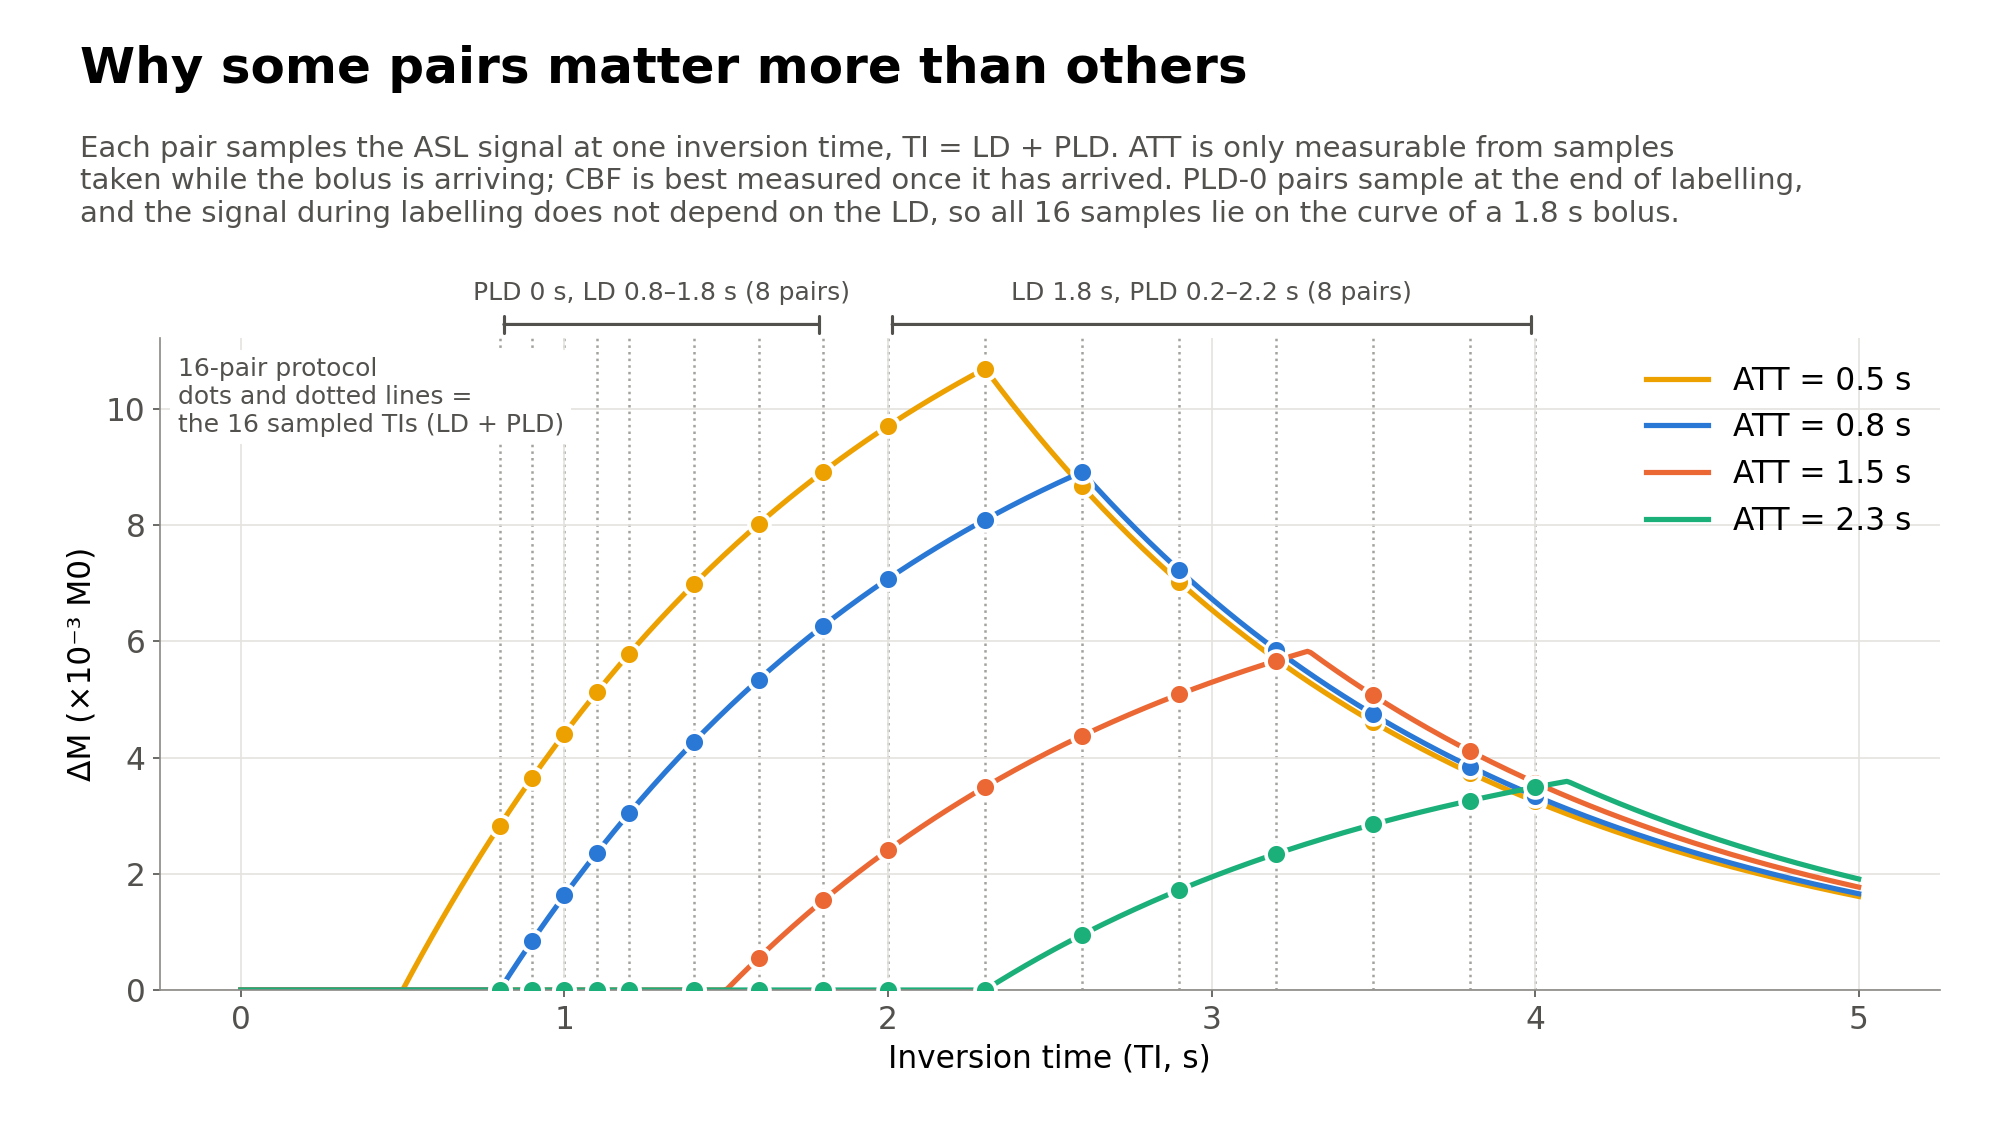

In [4]:
def fig_signal():
    sc = SCENARIOS["16-pair"]
    lds, plds = np.array(sc["taus"]), np.array(sc["plds"])
    samples = lds + plds
    model = opt.BuxtonPcasl(opt.PhysParams(f=50 / 6000))
    t = np.linspace(0, 5, 500)
    fig, ax = plt.subplots(figsize=SLIDE)
    fig.subplots_adjust(left=0.08, right=0.97, top=0.70, bottom=0.12)
    fig.suptitle("Why some pairs matter more than others", x=0.04, ha="left", fontsize=24, fontweight="bold", y=0.96)
    fig.text(0.04, 0.88, "Each pair samples the ASL signal at one inversion time, TI = LD + PLD. ATT is only measurable from samples\n"
             "taken while the bolus is arriving; CBF is best measured once it has arrived. PLD-0 pairs sample at the end of labelling,\n"
             "and the signal during labelling does not depend on the LD, so all 16 samples lie on the curve of a 1.8 s bolus.",
             fontsize=14, color=INK2, va="top")
    for t_sample in samples:
        ax.axvline(t_sample, color=MUTED, ls=":", lw=1.2, zorder=0)
    for att, color in ((0.5, "#eda100"), (0.8, BLUE), (1.5, ORANGE), (2.3, AQUA)):
        s = model.signal(np.array(1.8), t, np.array([att]))[:, 0]
        ax.plot(t, s * 1e3, color=color, label=f"ATT = {att:g} s")
        ss = model.signal(lds, samples, np.array([att]))[:, 0]      # each pair with its own LD
        ax.plot(samples, ss * 1e3, "o", ms=10, color=color, mec="white", mew=1.8, zorder=4)
    top = ax.get_ylim()[1]
    for (t0, t1), text in (((lds[plds == 0].min(), lds[plds == 0].max()), "PLD 0 s, LD 0.8–1.8 s (8 pairs)"),
                           ((samples[plds > 0].min(), samples[plds > 0].max()), "LD 1.8 s, PLD 0.2–2.2 s (8 pairs)")):
        ax.annotate("", (t1, top * 1.02), (t0, top * 1.02), annotation_clip=False,
                    arrowprops=dict(arrowstyle="|-|", color=INK2, lw=1.5, mutation_scale=4))
        ax.text((t0 + t1) / 2, top * 1.05, text, ha="center", va="bottom", fontsize=12, color=INK2)
    ax.set_ylim(0, top)
    ax.set_xlabel("Inversion time (TI, s)"); ax.set_ylabel("ΔM (×10⁻³ M0)")
    ax.legend(loc="upper right")
    ax.text(0.01, 0.97, "16-pair protocol\ndots and dotted lines =\nthe 16 sampled TIs (LD + PLD)", transform=ax.transAxes,
            ha="left", va="top", fontsize=12, color=INK2, zorder=5,
            bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="none"))
    return save(fig, "02_why_pairs_differ.png")


show(fig_signal())

## 03 · Which ATTs can a protocol estimate?
The estimable window runs from just after the shortest PLD to just before the second-longest LD+PLD. The cost is averaged over ATT 0.5–2.5 s inside that window (black bar), not the whole window: the window's ends rest on one or two delays, which would make those delays infinitely costly to lose.

wrote scrubbing_figures/03_estimable_att_window.png


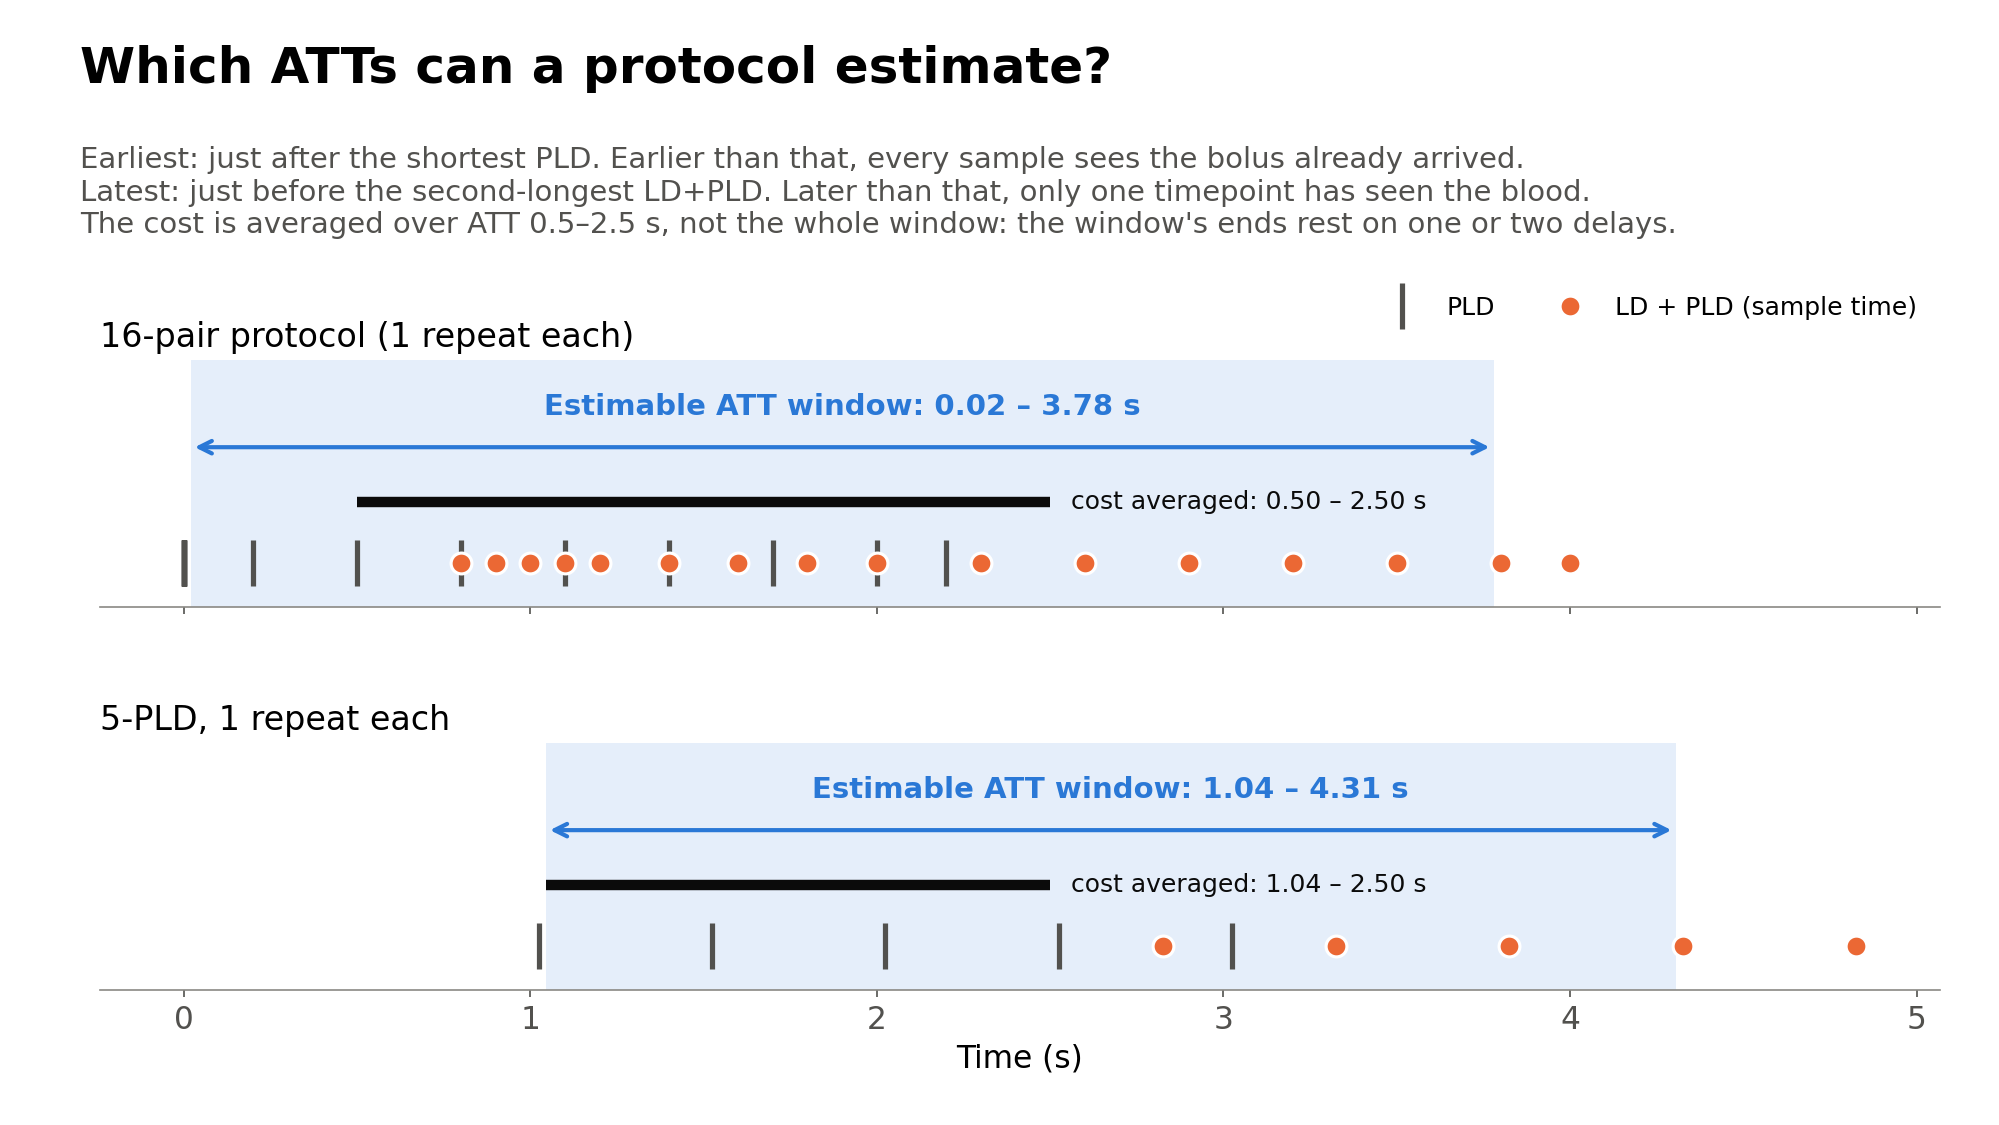

In [5]:
def fig_att_window():
    fig, axes = plt.subplots(2, 1, figsize=SLIDE, sharex=True)
    fig.subplots_adjust(left=0.05, right=0.97, top=0.68, bottom=0.12, hspace=0.55)
    fig.suptitle("Which ATTs can a protocol estimate?", x=0.04, ha="left", fontsize=24, fontweight="bold", y=0.96)
    fig.text(0.04, 0.87, "Earliest: just after the shortest PLD. Earlier than that, every sample sees the bolus already arrived.\n"
             "Latest: just before the second-longest LD+PLD. Later than that, only one timepoint has seen the blood.\n"
             "The cost is averaged over ATT 0.5–2.5 s, not the whole window: the window's ends rest on one or two delays.",
             fontsize=14, color=INK2, va="top")
    for ax, key in zip(axes, ("16-pair", "5x1")):
        sc = SCENARIOS[key]
        sa = sc["sa"]
        lo, hi = (v[0] for v in sa.estimable_range(sa.repeats))
        ax.axvspan(lo, hi, color=BLUE, alpha=0.12, lw=0)
        ax.annotate("", (hi, 0.55), (lo, 0.55), arrowprops=dict(arrowstyle="<->", color=BLUE, lw=2))
        ax.text((lo + hi) / 2, 0.66, f"Estimable ATT window: {lo:.2f} – {hi:.2f} s", ha="center",
                fontsize=14, color=BLUE, fontweight="bold")
        c_lo, c_hi = max(DEFAULT_ATT_RANGE[0], lo), min(DEFAULT_ATT_RANGE[1], hi)
        ax.plot([c_lo, c_hi], [0.36, 0.36], color=INK, lw=5, solid_capstyle="butt")
        ax.text(c_hi + 0.06, 0.36, f"cost averaged: {c_lo:.2f} – {c_hi:.2f} s", fontsize=12, color=INK, va="center")
        ax.plot(sa.plds, np.full(sa.ndelays, 0.15), "|", ms=22, mew=2.5, color=INK2, label="PLD")
        ax.plot(sa.lds + sa.plds, np.full(sa.ndelays, 0.15), "o", ms=10, color=ORANGE, mec="white", mew=1.5,
                label="LD + PLD (sample time)")
        ax.set_yticks([]); ax.set_ylim(0, 0.85); ax.grid(False)
        ax.spines["left"].set_visible(False)
        ax.set_title(sc["title"], loc="left", fontsize=16)
    axes[0].legend(loc="upper right", ncol=2, fontsize=12, bbox_to_anchor=(1, 1.35))
    axes[1].set_xlabel("Time (s)")
    return save(fig, "03_estimable_att_window.png")


show(fig_att_window())

## 04 · Cost of losing one pair
SD increase from removing a single pair at each LD/PLD. A few delays carry most of the information; pairs that only inform ATTs outside 0.5–2.5 s (e.g. PLD 0 with short LDs) are almost free. Where a loss leaves part of 0.5–2.5 s ATT-inestimable (e.g. PLD 1.025 s of the 5-PLD protocol), CBF and ATT are costed there with a Gaussian ATT prior of 1.3 ± 1.0 s, and the bar notes the ATT range that needed it. CBF then has a finite cost; ATT's cost there mostly reflects the prior.

wrote scrubbing_figures/04_cost_of_one_pair.png


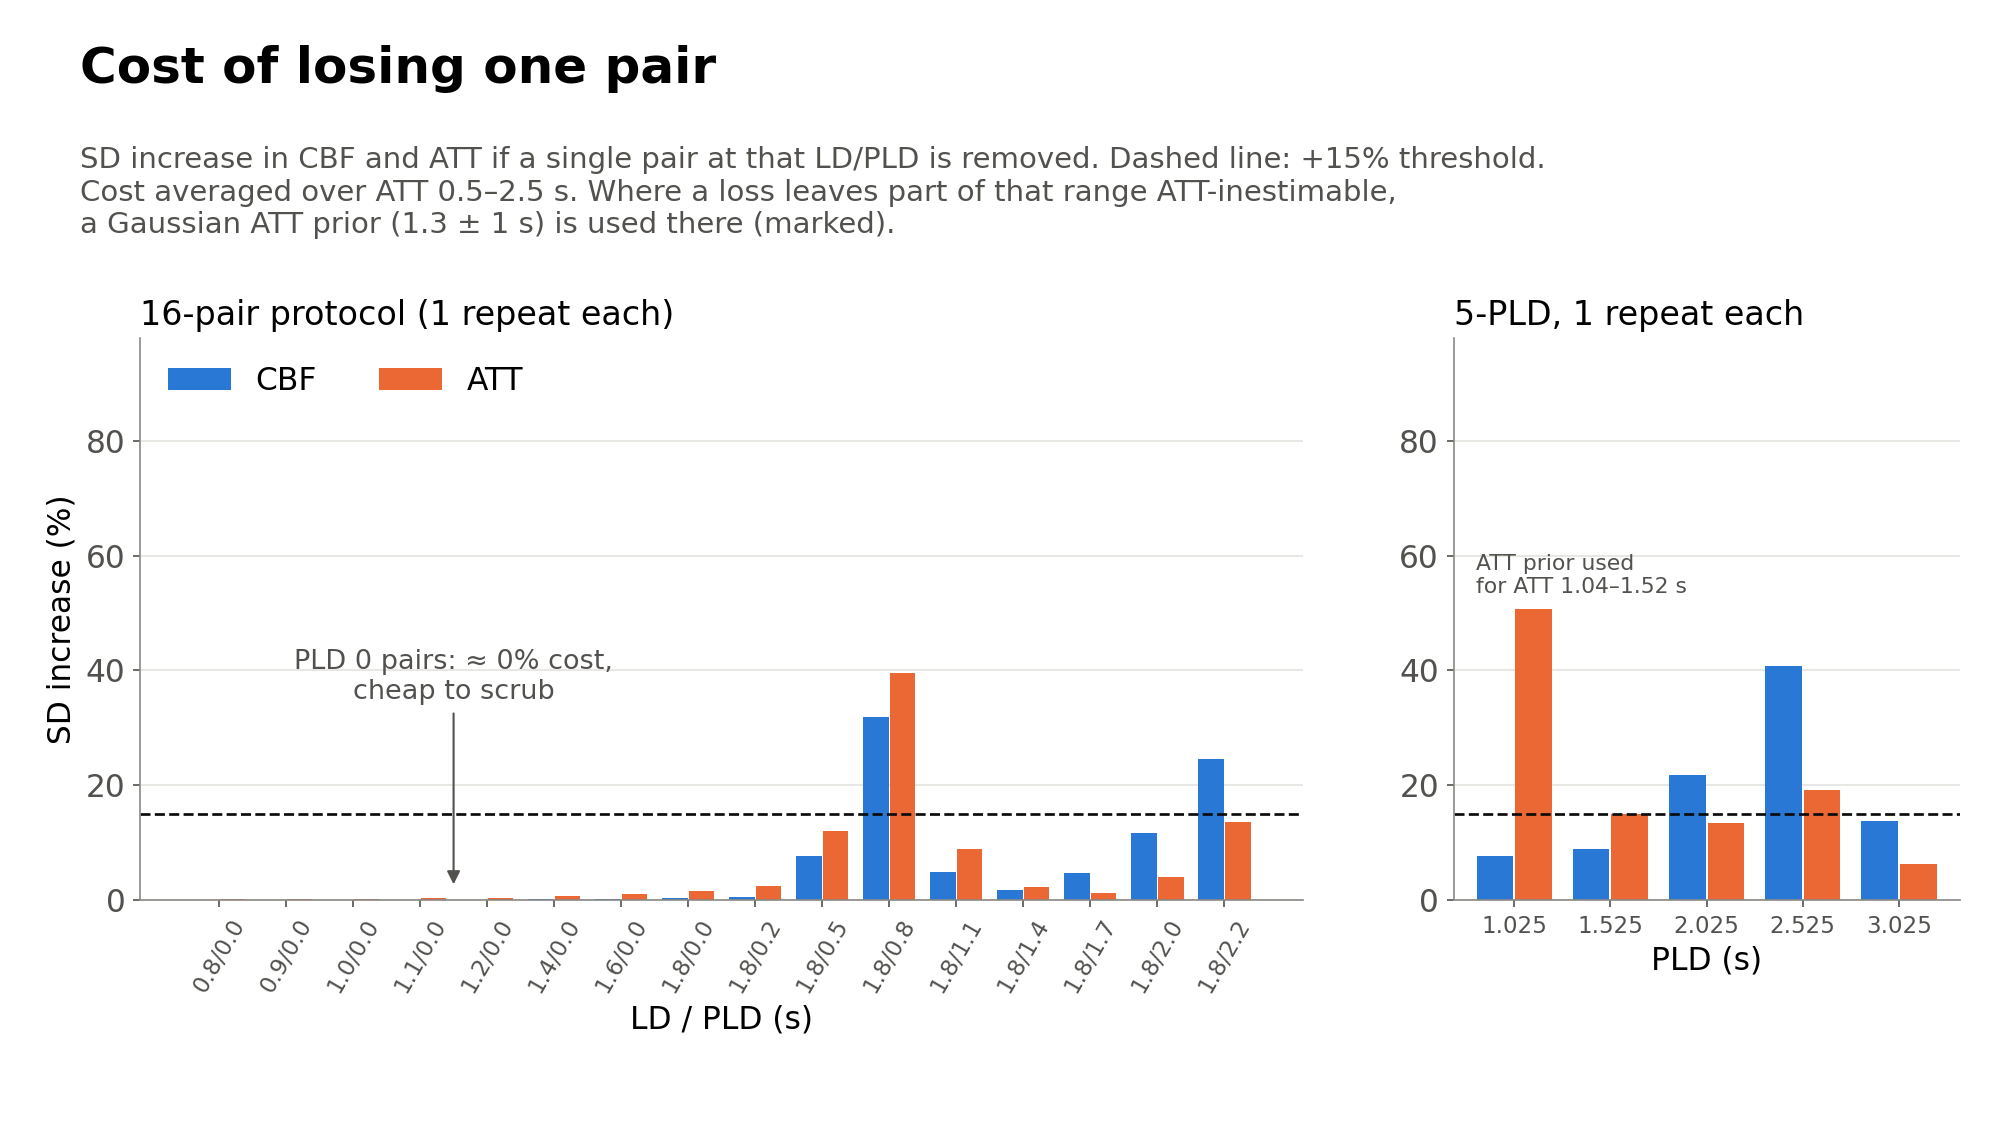

In [6]:
def single_costs(sa):
    trials = np.tile(sa.repeats, (sa.ndelays, 1)) - np.eye(sa.ndelays, dtype=int)
    return sa.sd_increase(trials, "CBF"), sa.sd_increase(trials, "ATT")


def cost_bars(ax, sc, cap=80):
    sa = sc["sa"]
    cbf, att = single_costs(sa)
    x = np.arange(sa.ndelays)
    w = 0.4
    for vals, off, color, label in ((cbf, -w / 2, BLUE, "CBF"), (att, w / 2, ORANGE, "ATT")):
        inf = ~np.isfinite(vals)
        shown = np.where(inf, cap, np.minimum(vals * 100, cap))
        bars = ax.bar(x + off, shown, w * 0.95, color=color, label=label)
        for b, is_inf in zip(bars, inf):
            if is_inf:
                b.set_hatch("//"); b.set_facecolor("white"); b.set_edgecolor(color)
    for d in np.where(~np.isfinite(att) | ~np.isfinite(cbf))[0]:
        ax.text(d, cap + 1, "∞", ha="center", va="bottom", fontsize=16, color=INK)
    trials = np.tile(sa.repeats, (sa.ndelays, 1)) - np.eye(sa.ndelays, dtype=int)
    for d in range(sa.ndelays):
        note = prior_note(sa, trials[d])
        if note:
            top = max(min(v * 100, cap) for v in (cbf[d], att[d]) if np.isfinite(v))
            ax.annotate(note.replace("prior for ", "ATT prior used\nfor "), (d - 0.4, top), xytext=(0, 6),
                        textcoords="offset points", ha="left", va="bottom", fontsize=10.5, color=INK2)
    ax.axhline(15, color=INK, ls="--", lw=1.3)
    ax.set_ylim(0, cap + 18); ax.set_ylabel("SD increase (%)")
    labels = [f"{p:g}" if np.allclose(sa.lds, sa.lds[0]) else f"{l:.1f}/{p:.1f}" for l, p in zip(sa.lds, sa.plds)]
    ax.set_xticks(x, labels, fontsize=11, rotation=0 if len(x) < 8 else 60)
    ax.set_xlabel("PLD (s)" if np.allclose(sa.lds, sa.lds[0]) else "LD / PLD (s)")
    ax.grid(axis="x", visible=False)


def fig_single_pair():
    fig, axes = plt.subplots(1, 2, figsize=SLIDE, gridspec_kw={"width_ratios": [2.3, 1]})
    fig.subplots_adjust(left=0.07, right=0.98, top=0.70, bottom=0.2, wspace=0.18)
    fig.suptitle("Cost of losing one pair", x=0.04, ha="left", fontsize=24, fontweight="bold", y=0.96)
    fig.text(0.04, 0.87, "SD increase in CBF and ATT if a single pair at that LD/PLD is removed. "
             "Dashed line: +15% threshold.\nCost averaged over ATT 0.5–2.5 s. Where a loss leaves part of that range "
             "ATT-inestimable,\na " + PRIOR_TEXT + " is used there (marked).",
             fontsize=14, color=INK2, va="top")
    for ax, key in zip(axes, ("16-pair", "5x1")):
        cost_bars(ax, SCENARIOS[key])
        ax.set_title(SCENARIOS[key]["title"], loc="left", fontsize=16)
    axes[0].legend(loc="upper left", ncol=2)
    axes[0].annotate("PLD 0 pairs: ≈ 0% cost,\ncheap to scrub", (3.5, 2), xytext=(3.5, 35), ha="center", fontsize=13,
                     color=INK2, arrowprops=dict(arrowstyle="-|>", color=INK2))
    axes[1].set_ylabel("")
    return save(fig, "04_cost_of_one_pair.png")


show(fig_single_pair())

## 05 · Scrubbing decisions: two protocols
Flagged pairs are taken worst motion first. Each is scrubbed only if the joint loss stays within 25% of the data and +15% SD for both CBF and ATT; otherwise it is kept despite the motion.

wrote scrubbing_figures/05_decisions_two_protocols.png


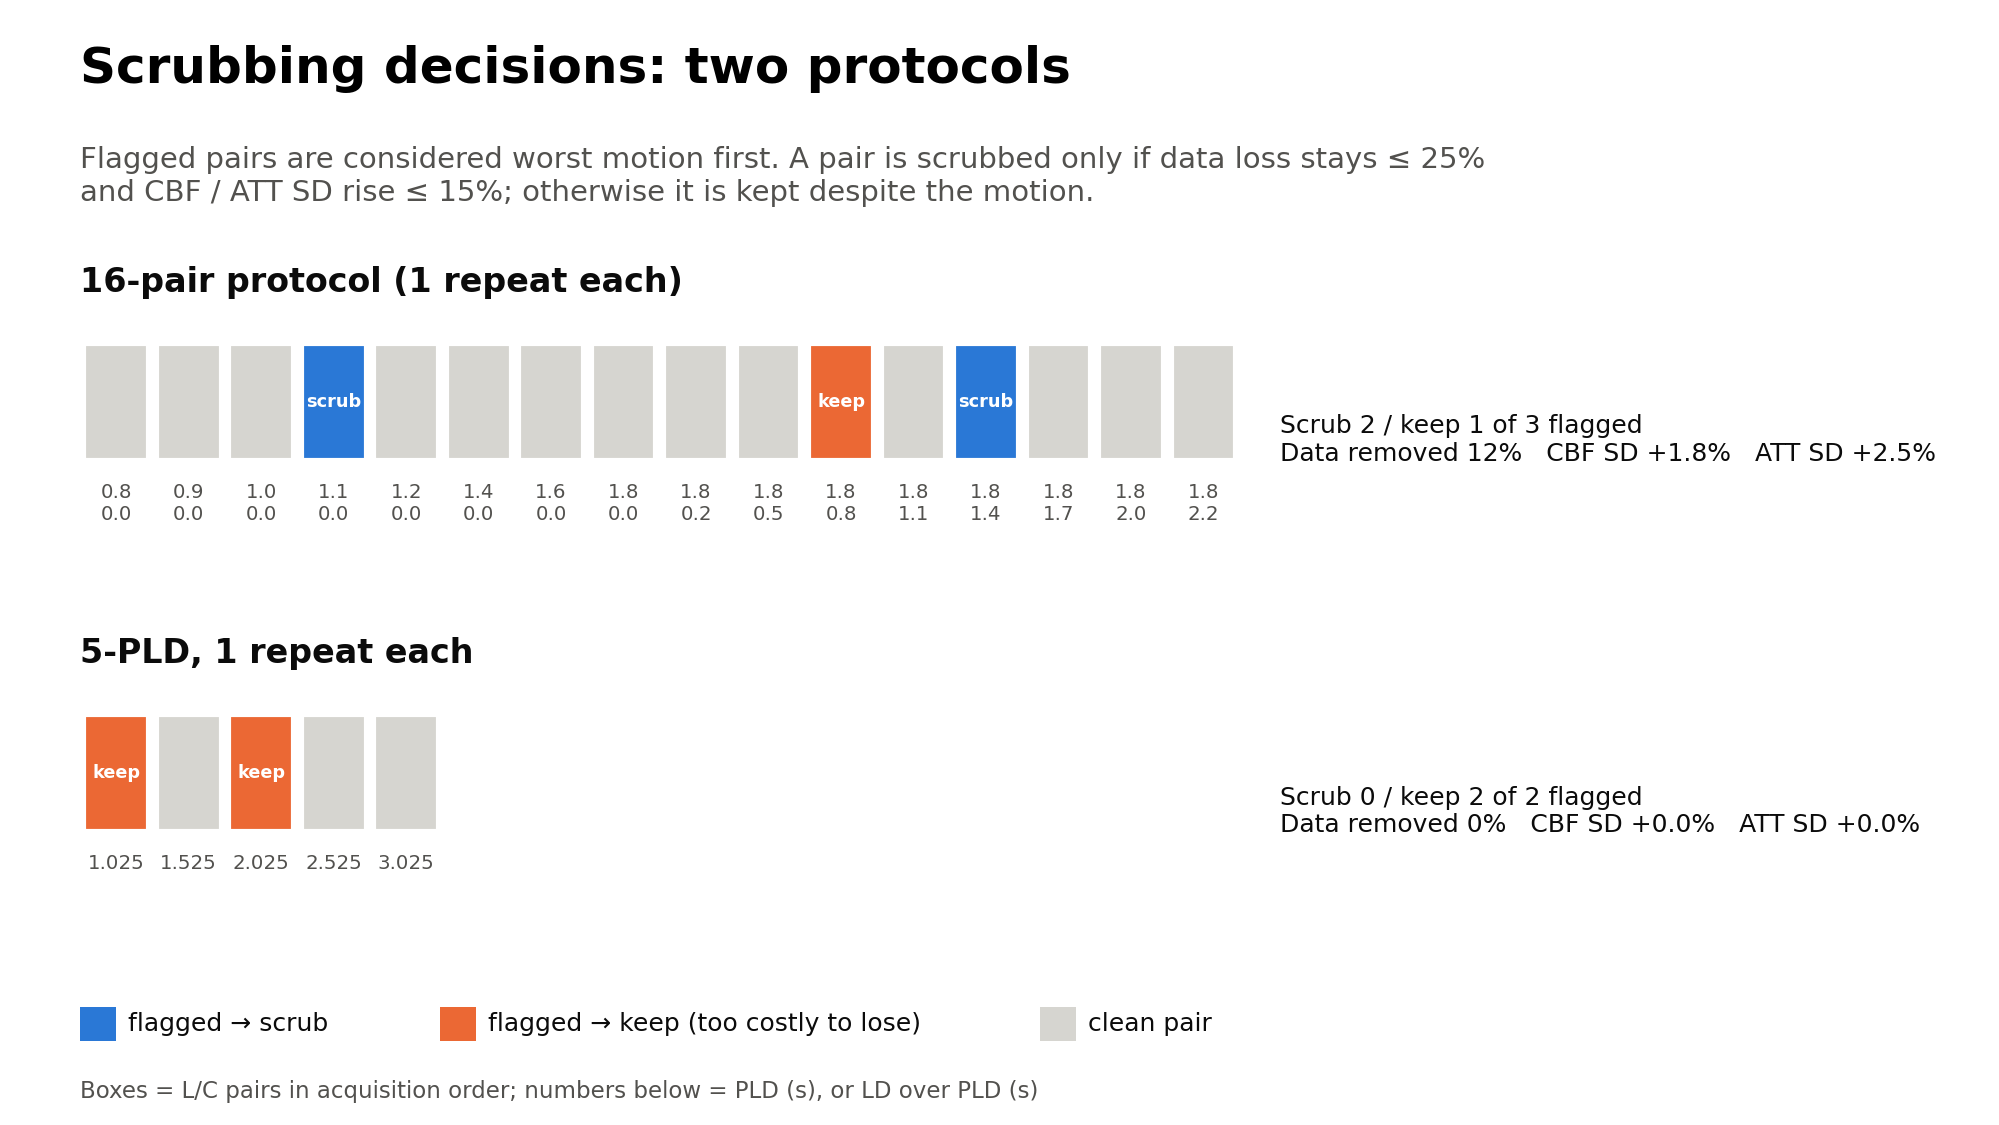

In [7]:
def decision_strip(ax, sc):
    sa = sc["sa"]
    for p in range(sa.npairs):
        if p in sc["removed"]:
            color, txt = SCRUB, "scrub"
        elif p in sc["retained"]:
            color, txt = KEEP, "keep"
        else:
            color, txt = CLEAN, ""
        ax.add_patch(Rectangle((p + 0.06, 0.06), 0.88, 0.88, fc=color, ec="white", lw=2))
        if txt:
            ax.text(p + 0.5, 0.5, txt, ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
        d = sa.delay_of_pair[p]
        lab = f"{sa.plds[d]:g}" if np.allclose(sa.lds, sa.lds[0]) else f"{sa.lds[d]:.1f}\n{sa.plds[d]:.1f}"
        ax.text(p + 0.5, -0.12, lab, ha="center", va="top", fontsize=9.5, color=INK2)
    ax.set_xlim(0, 16); ax.set_ylim(-0.7, 1)
    ax.axis("off")


def outcome_text(sc):
    sa, c = sc["sa"], sc["counts"]
    loss = 1 - c.sum() / sa.npairs
    return (f"Scrub {len(sc['removed'])} / keep {len(sc['retained'])} of {len(sc['flagged'])} flagged\n"
            f"Data removed {loss:.0%}   CBF SD {fmt(sa.sd_increase(c, 'CBF'))}   ATT SD {fmt(sa.sd_increase(c, 'ATT'))}")


def fig_decisions(keys, name, title, subtitle):
    fig = plt.figure(figsize=SLIDE)
    fig.suptitle(title, x=0.04, ha="left", fontsize=24, fontweight="bold", y=0.96)
    fig.text(0.04, 0.87, subtitle, fontsize=14, color=INK2, va="top")
    n = len(keys)
    top, rowh = 0.8, 0.66 / n
    for i, key in enumerate(keys):
        sc = SCENARIOS[key]
        y = top - (i + 1) * rowh
        fig.text(0.04, y + rowh * 0.82, sc["title"], fontsize=16, fontweight="bold", color=INK)
        ax = fig.add_axes([0.04, y + rowh * 0.1, 0.58, rowh * 0.6])
        decision_strip(ax, sc)
        fig.text(0.64, y + rowh * 0.42, outcome_text(sc), fontsize=12, color=INK, va="center")
    for j, (color, lab) in enumerate(((SCRUB, "flagged → scrub"), (KEEP, "flagged → keep (too costly to lose)"),
                                      (CLEAN, "clean pair"))):
        x = [0.04, 0.22, 0.52][j]
        fig.patches.append(Rectangle((x, 0.075), 0.018, 0.03, transform=fig.transFigure, fc=color))
        fig.text(x + 0.024, 0.09, lab, fontsize=12, va="center", color=INK)
    fig.text(0.04, 0.03, "Boxes = L/C pairs in acquisition order; numbers below = PLD (s), or LD over PLD (s)",
             fontsize=11, va="center", color=INK2)
    return save(fig, name)


def fig_decisions_protocols():
    return fig_decisions(["16-pair", "5x1"], "05_decisions_two_protocols.png", "Scrubbing decisions: two protocols",
                  "Flagged pairs are considered worst motion first. A pair is scrubbed only if data loss stays ≤ 25%\n"
                  "and CBF / ATT SD rise ≤ 15%; otherwise it is kept despite the motion.")


show(fig_decisions_protocols())

## 06 · Scrubbing decisions: 1 vs 2 repeats
The same motion flags on the 5-PLD protocol acquired once or twice. With a second repeat, losing one pair no longer removes the timepoint, so more can be scrubbed.

wrote scrubbing_figures/06_decisions_repeats.png


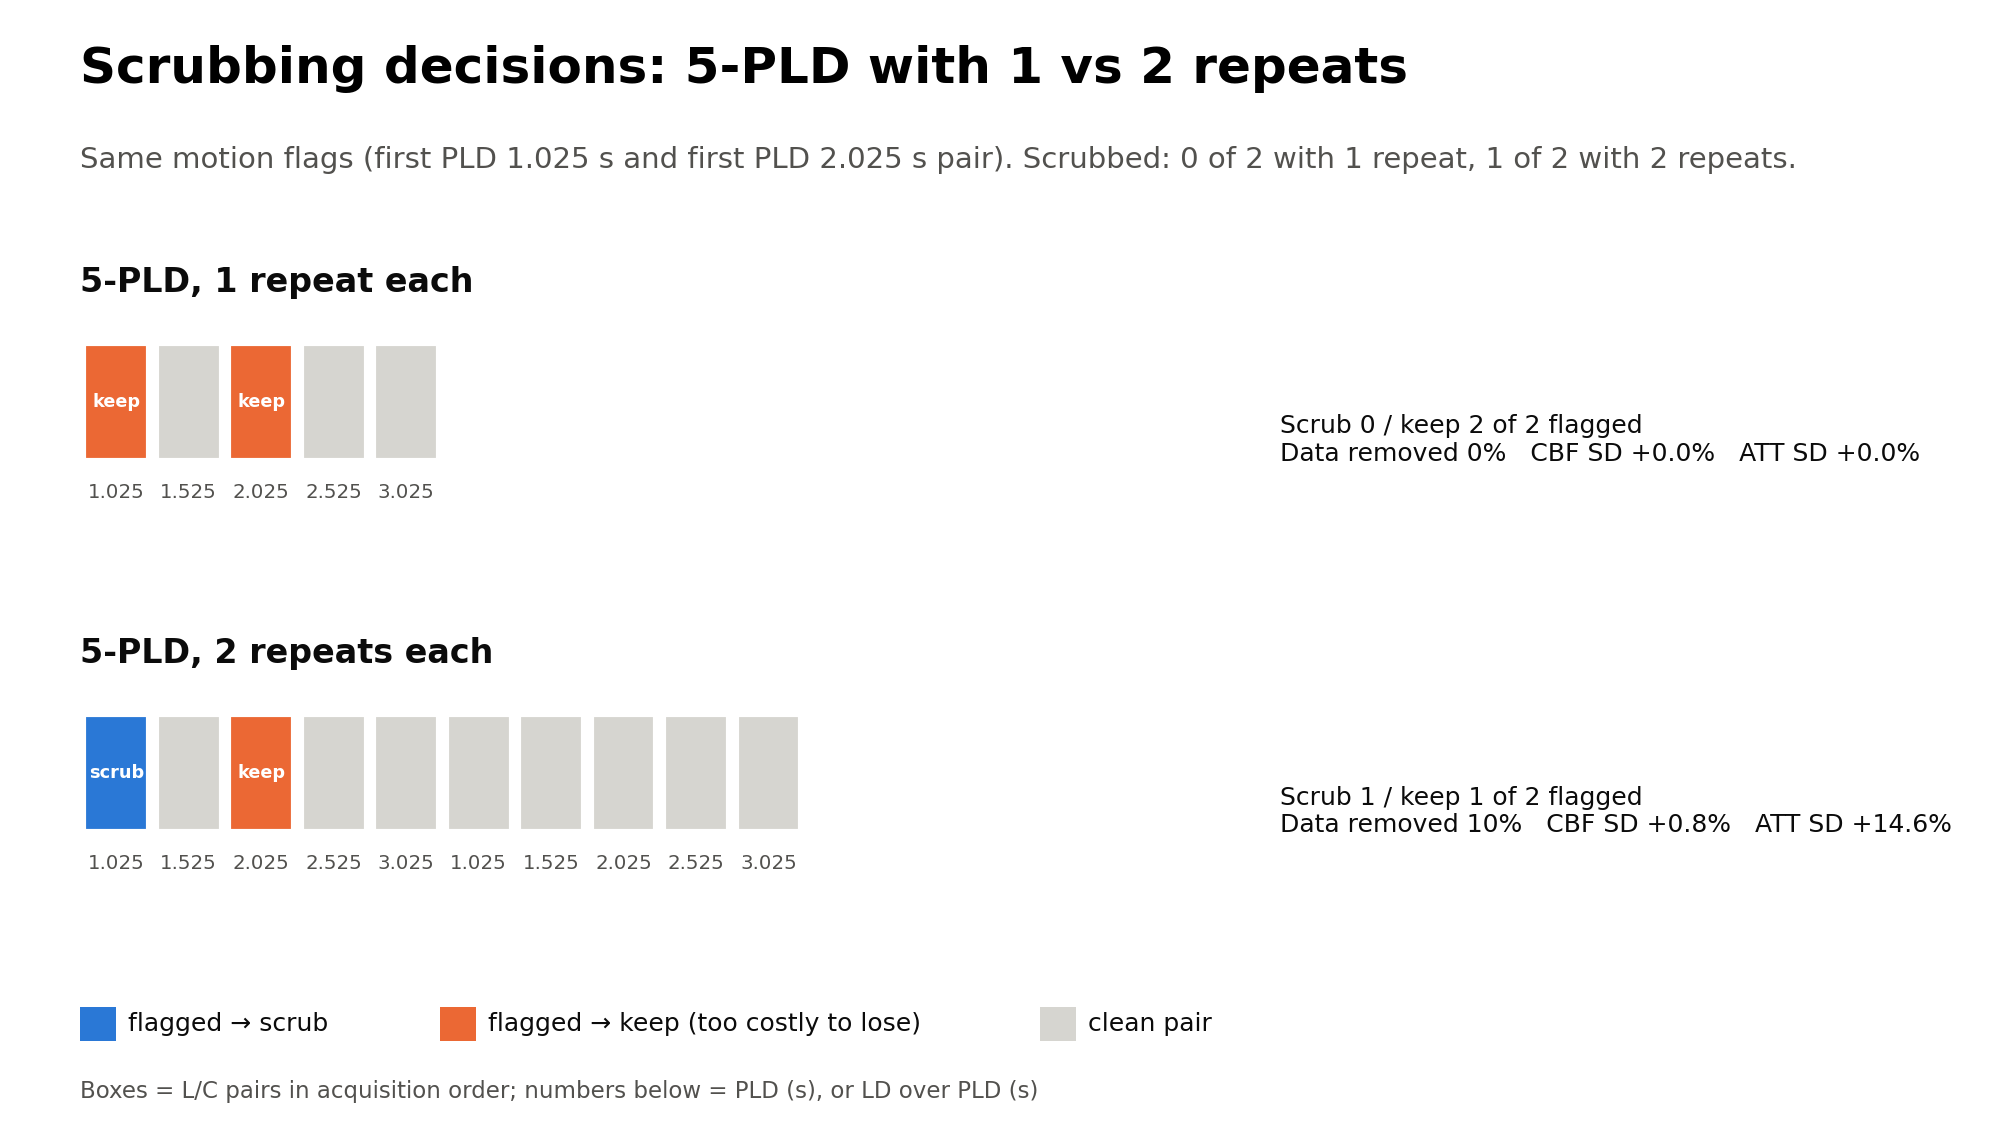

In [8]:
def fig_decisions_repeats():
    n1, n2 = len(SCENARIOS["5x1"]["removed"]), len(SCENARIOS["5x2"]["removed"])
    return fig_decisions(["5x1", "5x2"], "06_decisions_repeats.png", "Scrubbing decisions: 5-PLD with 1 vs 2 repeats",
                  "Same motion flags (first PLD 1.025 s and first PLD 2.025 s pair). "
                  f"Scrubbed: {n1} of 2 with 1 repeat, {n2} of 2 with 2 repeats.")


show(fig_decisions_repeats())

## 07 · Why repeats change the decision
Cost of losing one pair with 1 vs 2 repeats, and the resulting decisions. With one repeat every pair is an irreplaceable timepoint; with two, losing one only halves that delay's information.

wrote scrubbing_figures/07_repeats_change_decision.png


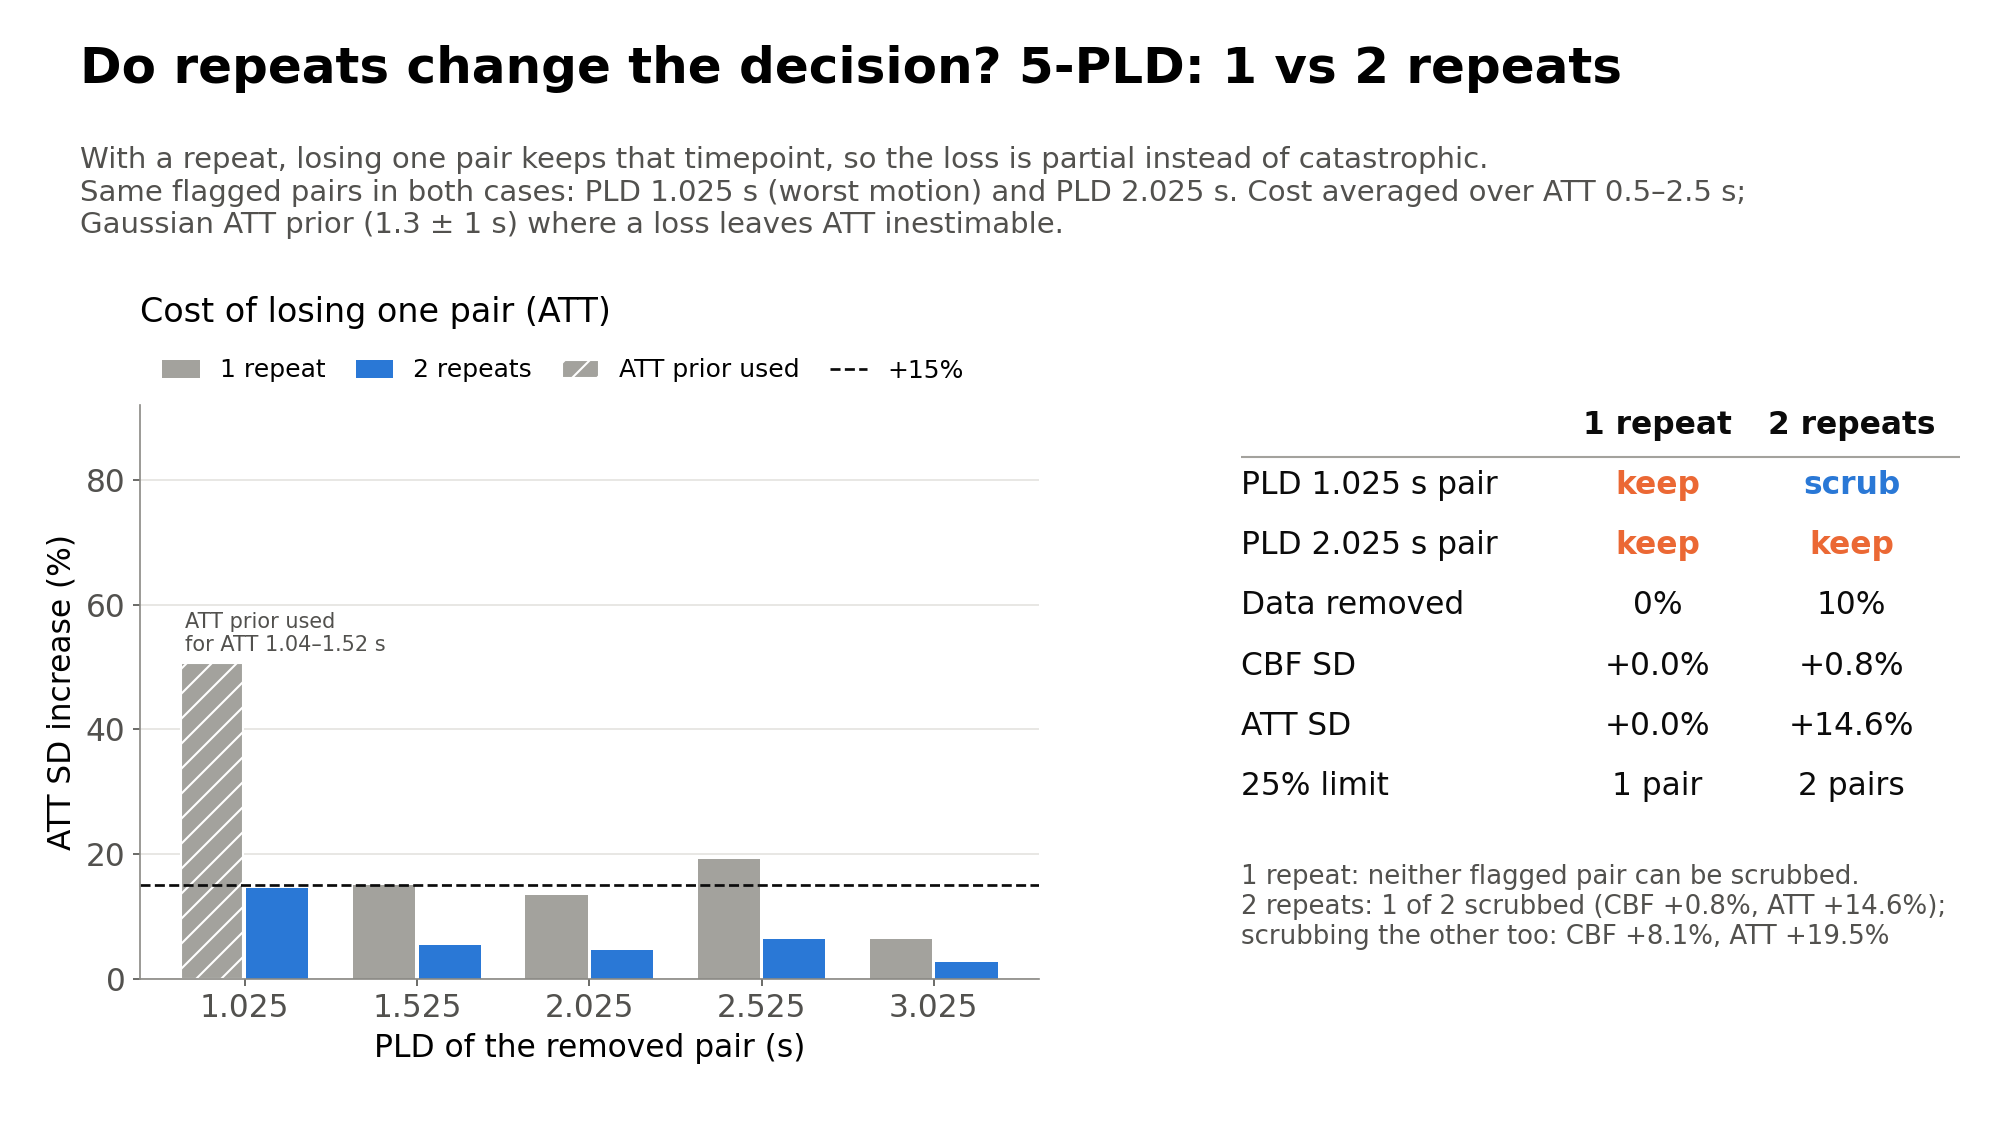

In [9]:
def repeat_summary(sc):
    """One-line description of a scenario's gate decision, computed from the results"""
    sa, n = sc["sa"], len(sc["removed"])
    if n == 0:
        return "neither flagged pair can be scrubbed."
    c = sc["counts"]
    text = (f"{n} of {len(sc['flagged'])} scrubbed (CBF {fmt(sa.sd_increase(c, 'CBF'))}, "
            f"ATT {fmt(sa.sd_increase(c, 'ATT'))});")
    if sc["retained"]:
        trial = sa.counts(sc["removed"] + sc["retained"][:1])
        text += (f"\nscrubbing the other too: CBF {fmt(sa.sd_increase(trial, 'CBF'))}, "
                 f"ATT {fmt(sa.sd_increase(trial, 'ATT'))}")
    return text


def fig_repeats():
    fig, axes = plt.subplots(1, 2, figsize=SLIDE, gridspec_kw={"width_ratios": [1.25, 1]})
    fig.subplots_adjust(left=0.07, right=0.98, top=0.64, bottom=0.13, wspace=0.25)
    fig.suptitle("Do repeats change the decision? 5-PLD: 1 vs 2 repeats", x=0.04, ha="left", fontsize=24,
                 fontweight="bold", y=0.96)
    fig.text(0.04, 0.87, "With a repeat, losing one pair keeps that timepoint, so the loss is partial instead of catastrophic.\n"
             "Same flagged pairs in both cases: PLD 1.025 s (worst motion) and PLD 2.025 s. Cost averaged over ATT 0.5–2.5 s;\n"
             + PRIOR_TEXT + " where a loss leaves ATT inestimable.",
             fontsize=14, color=INK2, va="top")

    ax = axes[0]
    cap = 80
    x = np.arange(len(FIVE))
    w = 0.38
    for key, off, color, label in (("5x1", -w / 2, MUTED, "1 repeat"), ("5x2", w / 2, BLUE, "2 repeats")):
        sa = SCENARIOS[key]["sa"]
        _, att = single_costs(sa)
        trials = np.tile(sa.repeats, (sa.ndelays, 1)) - np.eye(sa.ndelays, dtype=int)
        bars = ax.bar(x + off, np.minimum(np.nan_to_num(att, nan=np.inf), cap / 100) * 100, w * 0.95, color=color,
                      label=label)
        for b, trial in zip(bars, trials):
            note = prior_note(sa, trial)
            if note:
                b.set_hatch("//"); b.set_edgecolor("white")
                ax.annotate(note.replace("prior for ", "ATT prior used\nfor "), (b.get_x(), b.get_height()),
                            xytext=(2, 4), textcoords="offset points", ha="left", va="bottom", fontsize=10, color=INK2)
    ax.axhline(15, color=INK, ls="--", lw=1.3, label="threshold +15%")
    ax.set_xticks(x, [f"{p:g}" for p in FIVE]); ax.set_xlabel("PLD of the removed pair (s)")
    ax.set_ylabel("ATT SD increase (%)"); ax.set_ylim(0, cap + 12)
    ax.set_title("Cost of losing one pair (ATT)", loc="left", fontsize=16, pad=40)
    handles = [Patch(fc=MUTED, label="1 repeat"), Patch(fc=BLUE, label="2 repeats"),
               Patch(fc=MUTED, ec="white", hatch="//", label="ATT prior used"),
               Line2D([], [], color=INK, ls="--", lw=1.3, label="+15%")]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, 1.0), ncol=4, fontsize=12, handlelength=1.5,
              columnspacing=1.2)
    ax.grid(axis="x", visible=False)

    ax = axes[1]
    ax.axis("off")
    rows = [("", "1 repeat", "2 repeats")]
    s1, s2 = SCENARIOS["5x1"], SCENARIOS["5x2"]
    for pld_idx, lab in ((0, "PLD 1.025 s pair"), (2, "PLD 2.025 s pair")):
        rows.append((lab, "keep" if pld_idx in s1["retained"] else "scrub", "keep" if pld_idx in s2["retained"] else "scrub"))
    rows.append(("Data removed", f"{1 - s1['counts'].sum() / s1['sa'].npairs:.0%}", f"{1 - s2['counts'].sum() / s2['sa'].npairs:.0%}"))
    rows.append(("CBF SD", fmt(s1["sa"].sd_increase(s1["counts"], "CBF")), fmt(s2["sa"].sd_increase(s2["counts"], "CBF"))))
    rows.append(("ATT SD", fmt(s1["sa"].sd_increase(s1["counts"], "ATT")), fmt(s2["sa"].sd_increase(s2["counts"], "ATT"))))
    rows.append(("25% limit", f"{int(MAX_LOSS * s1['sa'].npairs)} pair", f"{int(MAX_LOSS * s2['sa'].npairs)} pairs"))
    for i, row in enumerate(rows):
        y = 0.95 - i * 0.105
        for j, cell in enumerate(row):
            color = {"keep": KEEP, "scrub": SCRUB}.get(cell, INK)
            ax.text([0.0, 0.58, 0.85][j], y, cell, transform=ax.transAxes, fontsize=15, ha="left" if j == 0 else "center",
                    color=color, fontweight="bold" if i == 0 or cell in ("keep", "scrub") else "normal")
        if i == 0:
            ax.plot([0, 1], [y - 0.04, y - 0.04], transform=ax.transAxes, color=MUTED, lw=1)
    ax.text(0.0, 0.2, f"1 repeat: {repeat_summary(s1)}\n2 repeats: {repeat_summary(s2)}",
            transform=ax.transAxes, fontsize=12.5, color=INK2, va="top")
    return save(fig, "07_repeats_change_decision.png")


show(fig_repeats())

## 08 · How fast does the cost grow as pairs are lost?
Mean (solid) and median (dashed) SD increase over every combination of k lost pairs. This is the evidence for setting the data-loss limit: the largest k whose mean stays within +15% is printed at the bottom. Where a combination leaves part of 0.5–2.5 s ATT-inestimable, both CBF and ATT are costed there with the ATT prior (1.3 ± 1.0 s); the lower row shows how often that happens.

wrote scrubbing_figures/08_cost_of_losing_k_pairs.png


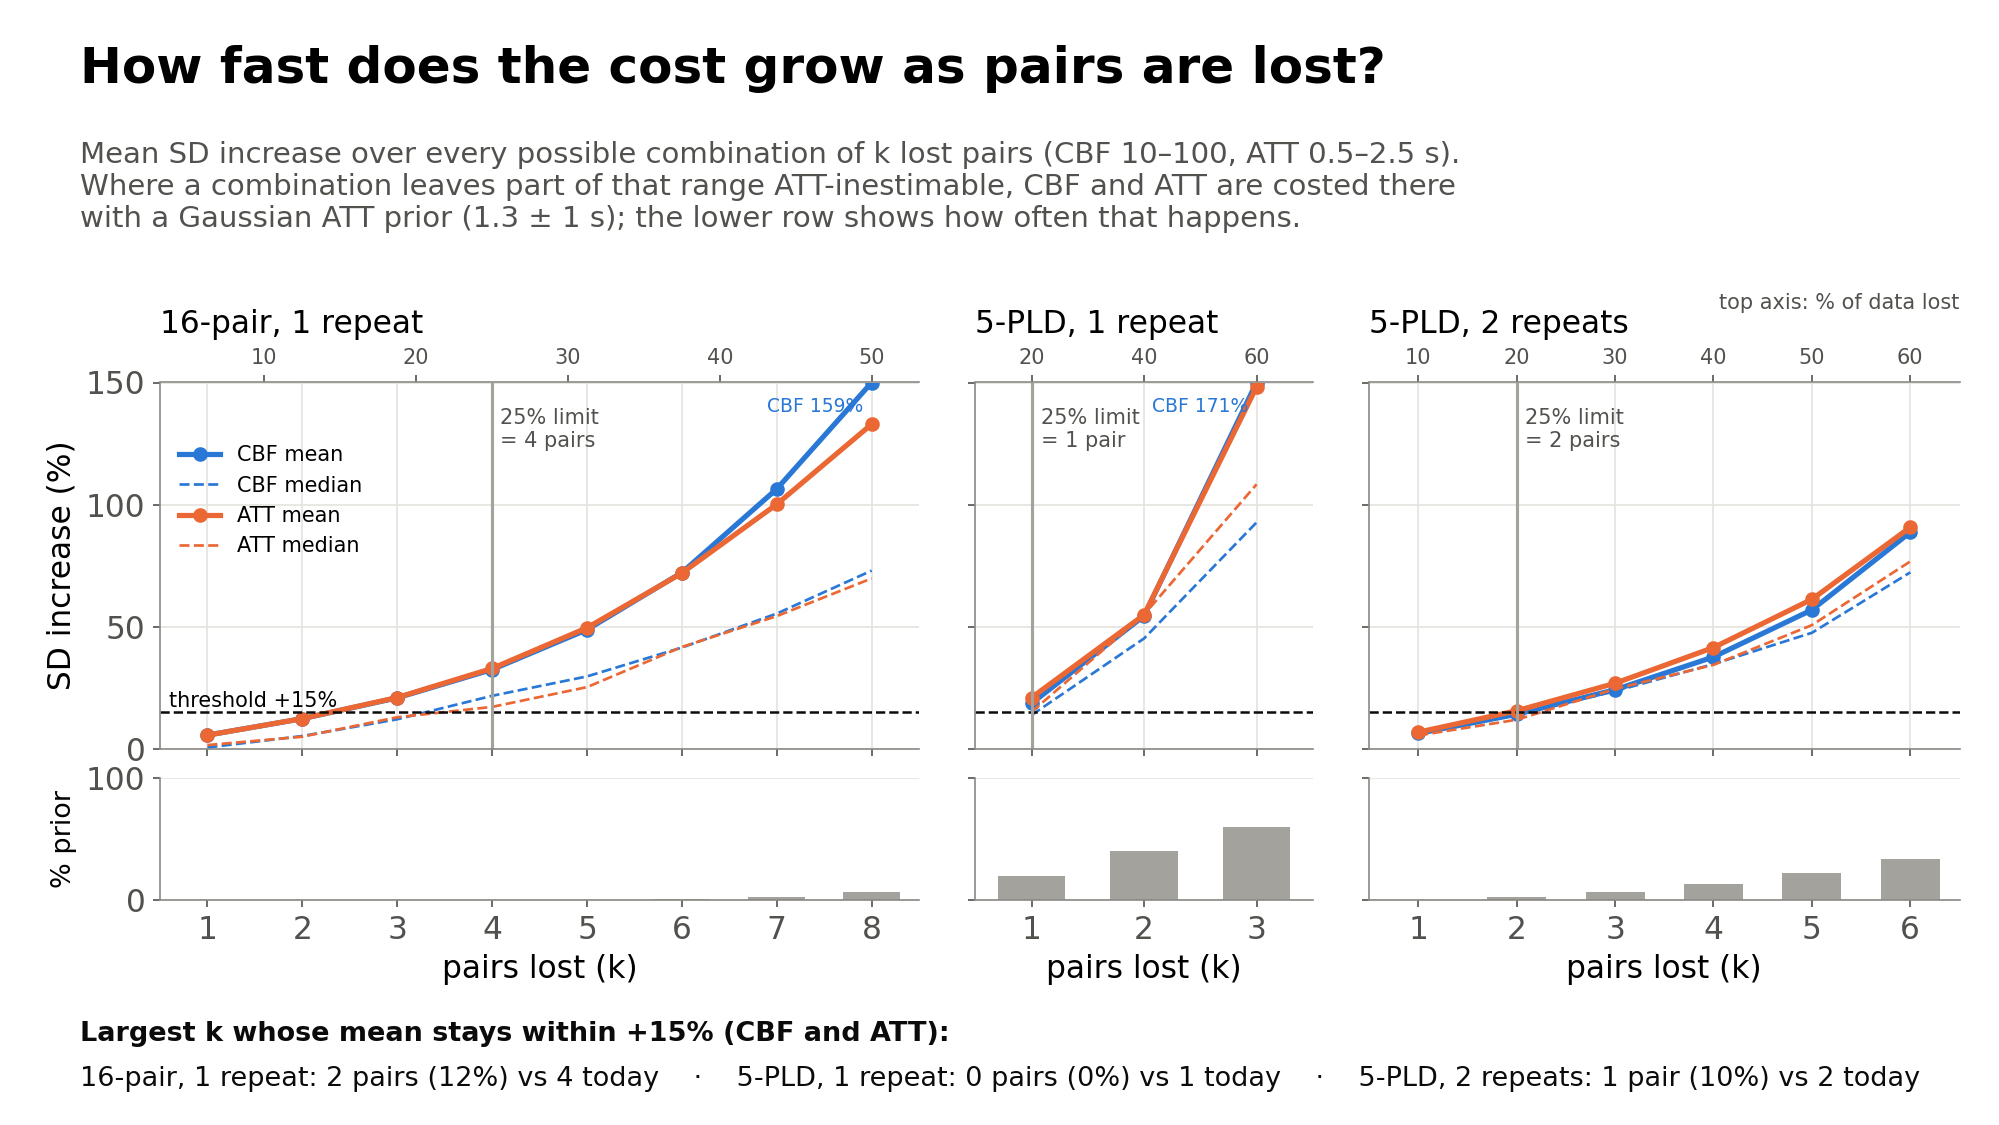

In [10]:
def loss_curve(sa, k_max, max_combinations=20000):
    """Mean / median SD increase over every combination of k lost pairs, with the share that needed the ATT prior"""
    rows = []
    for k in range(1, k_max + 1):
        combos = sa.combination_counts(k, max_combinations, rng=k)
        row = {"k": k}
        for m in ("CBF", "ATT"):
            inc, lo, hi = sa.sd_increase_in_range(combos, m)
            row[f"{m} mean"], row[f"{m} median"] = np.nanmean(inc), np.nanmedian(inc)
        row["prior"] = np.mean(sa.prior_atts(combos).any(axis=-1))
        rows.append(row)
    return rows


def fig_loss_curves():
    keys = [("16-pair", 8), ("5x1", 3), ("5x2", 6)]
    curves = {key: loss_curve(SCENARIOS[key]["sa"], k_max) for key, k_max in keys}
    fig, axes = plt.subplots(2, 3, figsize=SLIDE, sharey="row",
                             gridspec_kw={"width_ratios": [k + 1 for _, k in keys], "height_ratios": [3, 1]})
    fig.subplots_adjust(left=0.08, right=0.98, top=0.66, bottom=0.2, wspace=0.1, hspace=0.12)
    short_title = {"16-pair": "16-pair, 1 repeat", "5x1": "5-PLD, 1 repeat", "5x2": "5-PLD, 2 repeats"}
    fig.suptitle("How fast does the cost grow as pairs are lost?", x=0.04, ha="left", fontsize=24, fontweight="bold", y=0.96)
    fig.text(0.04, 0.875, "Mean SD increase over every possible combination of k lost pairs (CBF 10–100, ATT 0.5–2.5 s).\n"
             "Where a combination leaves part of that range ATT-inestimable, CBF and ATT are costed there\nwith a "
             + PRIOR_TEXT + "; the lower row shows how often that happens.",
             fontsize=14, color=INK2, va="top")
    ymax = 150
    summary = []
    for col, (key, k_max) in enumerate(keys):
        sa, rows = SCENARIOS[key]["sa"], curves[key]
        ks = np.array([r["k"] for r in rows])
        ax, axn = axes[0, col], axes[1, col]
        for m, color in (("CBF", BLUE), ("ATT", ORANGE)):
            mean = np.array([r[f"{m} mean"] for r in rows]) * 100
            ax.plot(ks, np.minimum(mean, ymax), color=color, marker="o", ms=6, label=f"{m} mean")
            for k, v in zip(ks, mean):
                if v > ymax:
                    ax.annotate(f"{m} {v:.0f}%", (k, ymax), xytext=(-4, -14 if m == "CBF" else -28),
                                textcoords="offset points", ha="right", fontsize=9, color=color)
            ax.plot(ks, np.minimum(np.array([r[f"{m} median"] for r in rows]) * 100, ymax), color=color, lw=1.3,
                    ls="--", label=f"{m} median")
        ax.axhline(15, color=INK, ls="--", lw=1.2)
        n_hard = int(MAX_LOSS * sa.npairs + 1e-9)
        ax.axvline(n_hard, color=MUTED, lw=1.5)
        ax.text(n_hard + 0.08, ymax * 0.93, f"25% limit\n= {n_hard} pair{'s' if n_hard != 1 else ''}", fontsize=10,
                color=INK2, va="top")
        within = [(r["CBF mean"] <= 0.15) and (r["ATT mean"] <= 0.15) for r in rows]
        k_ok = int(np.cumprod(within).sum())
        summary.append(f"{short_title[key]}: {k_ok} pair{'s' if k_ok != 1 else ''} ({k_ok / sa.npairs:.0%}) "
                       f"vs {n_hard} today")
        ax.set_ylim(0, ymax); ax.set_xlim(0.5, k_max + 0.5); ax.set_xticks(ks)
        ax.tick_params(labelbottom=False)
        ax.set_title(short_title[key], loc="left", fontsize=15, pad=24)
        sec = ax.secondary_xaxis("top", functions=(lambda k, n=sa.npairs: 100 * k / n, lambda q, n=sa.npairs: q * n / 100))
        sec.tick_params(labelsize=10)
        axn.bar(ks, [100 * r["prior"] for r in rows], color=MUTED, width=0.6)
        axn.set_ylim(0, 100); axn.set_xlim(0.5, k_max + 0.5); axn.set_xticks(ks)
        axn.set_xlabel("pairs lost (k)"); axn.grid(axis="x", visible=False)
    axes[0, 0].set_ylabel("SD increase (%)")
    axes[1, 0].set_ylabel("% prior", fontsize=13)
    axes[0, 0].text(0.6, 17, "threshold +15%", fontsize=10)
    axes[0, 0].legend(loc="upper left", fontsize=10, ncol=1, bbox_to_anchor=(0.0, 0.88))
    fig.text(0.04, 0.075, "Largest k whose mean stays within +15% (CBF and ATT):", fontsize=13, color=INK,
             fontweight="bold")
    fig.text(0.04, 0.035, "    ·    ".join(summary), fontsize=13, color=INK)
    fig.text(0.98, 0.725, "top axis: % of data lost", fontsize=10, color=INK2, ha="right")
    return save(fig, "08_cost_of_losing_k_pairs.png")


show(fig_loss_curves())

## 09 · When does scrubbing become damaging?
Pairs removed one at a time, choosing the least- (aqua) or most-damaging (orange) pair at each step: the range between the two lines is how much the choice of pairs matters. Lines leaving the top exceed +60%.

wrote scrubbing_figures/09_when_scrubbing_damages.png


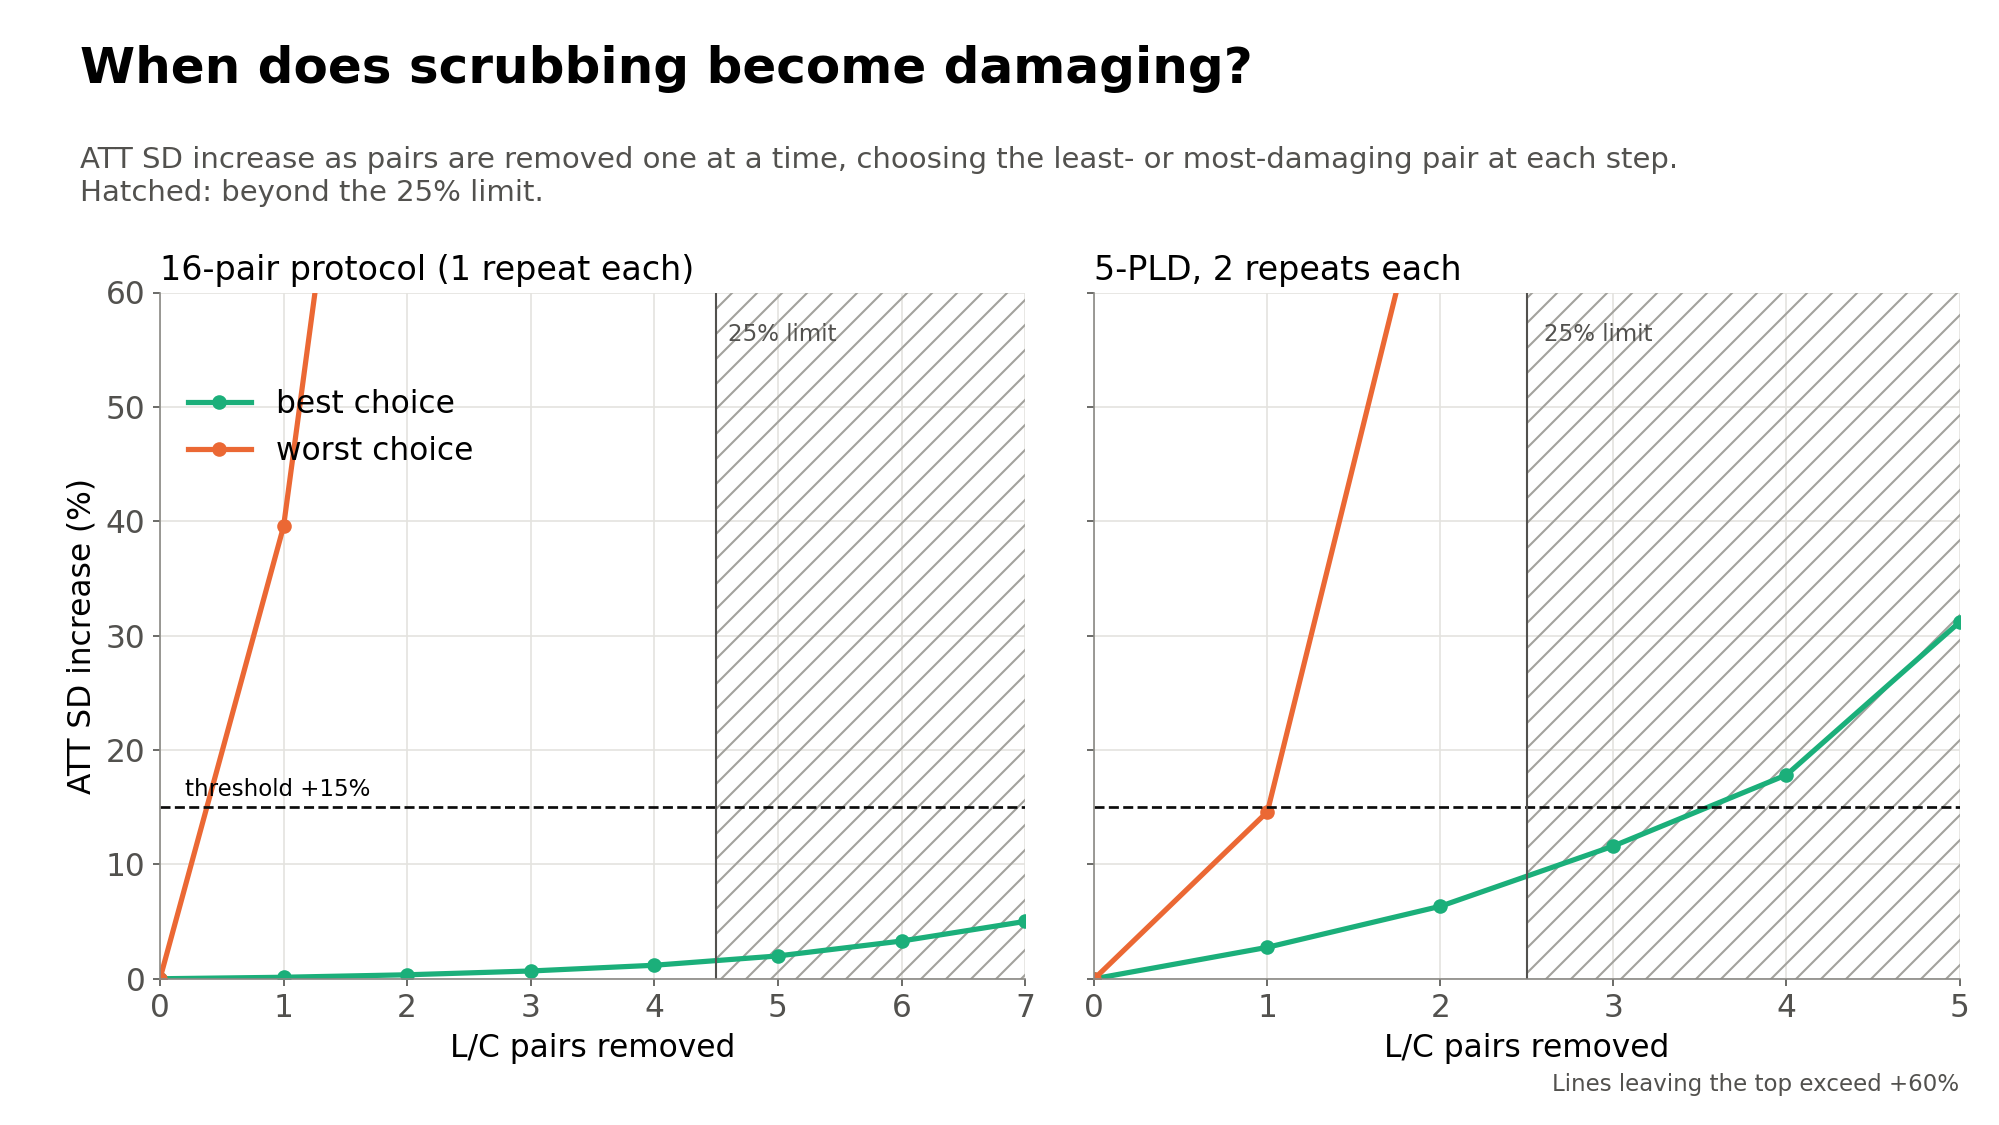

In [11]:
def fig_damage():
    fig, axes = plt.subplots(1, 2, figsize=SLIDE, sharey=True)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.74, bottom=0.13, wspace=0.08)
    fig.suptitle("When does scrubbing become damaging?", x=0.04, ha="left", fontsize=24, fontweight="bold", y=0.96)
    fig.text(0.04, 0.87, "ATT SD increase as pairs are removed one at a time, choosing the least- or most-damaging pair at each step.\n"
             "Hatched: beyond the 25% limit.", fontsize=14, color=INK2, va="top")
    ymax = 60
    for ax, key in zip(axes, ("16-pair", "5x2")):
        sa = SCENARIOS[key]["sa"]
        n_hard = int(MAX_LOSS * sa.npairs)
        n_max = min(sa.npairs - 2, n_hard + 3)
        ks = np.arange(n_max + 1)
        clip = lambda v: np.minimum(np.nan_to_num(v, nan=np.inf), ymax * 0.02) * 100
        ax.plot(ks, clip(sa.sd_increase(sa.greedy_counts(n_max, "ATT", False), "ATT")), color=AQUA, marker="o", label="best choice")
        ax.plot(ks, clip(sa.sd_increase(sa.greedy_counts(n_max, "ATT", True), "ATT")), color=ORANGE, marker="o", label="worst choice")
        ax.axhline(15, color=INK, ls="--", lw=1.3)
        ax.axvspan(n_hard + 0.5, n_max, facecolor="none", edgecolor=MUTED, hatch="//", lw=0)
        ax.axvline(n_hard + 0.5, color=INK2, lw=1)
        ax.set_xlim(0, n_max); ax.set_ylim(0, ymax)
        ax.set_xlabel("L/C pairs removed"); ax.set_title(SCENARIOS[key]["title"], loc="left", fontsize=16)
        ax.text(n_hard + 0.6, ymax * 0.93, "25% limit", fontsize=11, color=INK2)
    axes[0].set_ylabel("ATT SD increase (%)")
    axes[0].text(0.2, 16, "threshold +15%", fontsize=11)
    axes[0].legend(loc="upper left", bbox_to_anchor=(0, 0.9))
    fig.text(0.98, 0.03, "Lines leaving the top exceed +60%", ha="right", fontsize=11, color=INK2)
    return save(fig, "09_when_scrubbing_damages.png")


show(fig_damage())

## 10 · Residual motion scrubbing: current vs proposed logic
qasl_qc `residual_motion.py` today (left: numbered problems) and with the CRLB sensitivity gate (right: new and changed steps tagged).

wrote scrubbing_figures/10_logic_current_vs_proposed.png


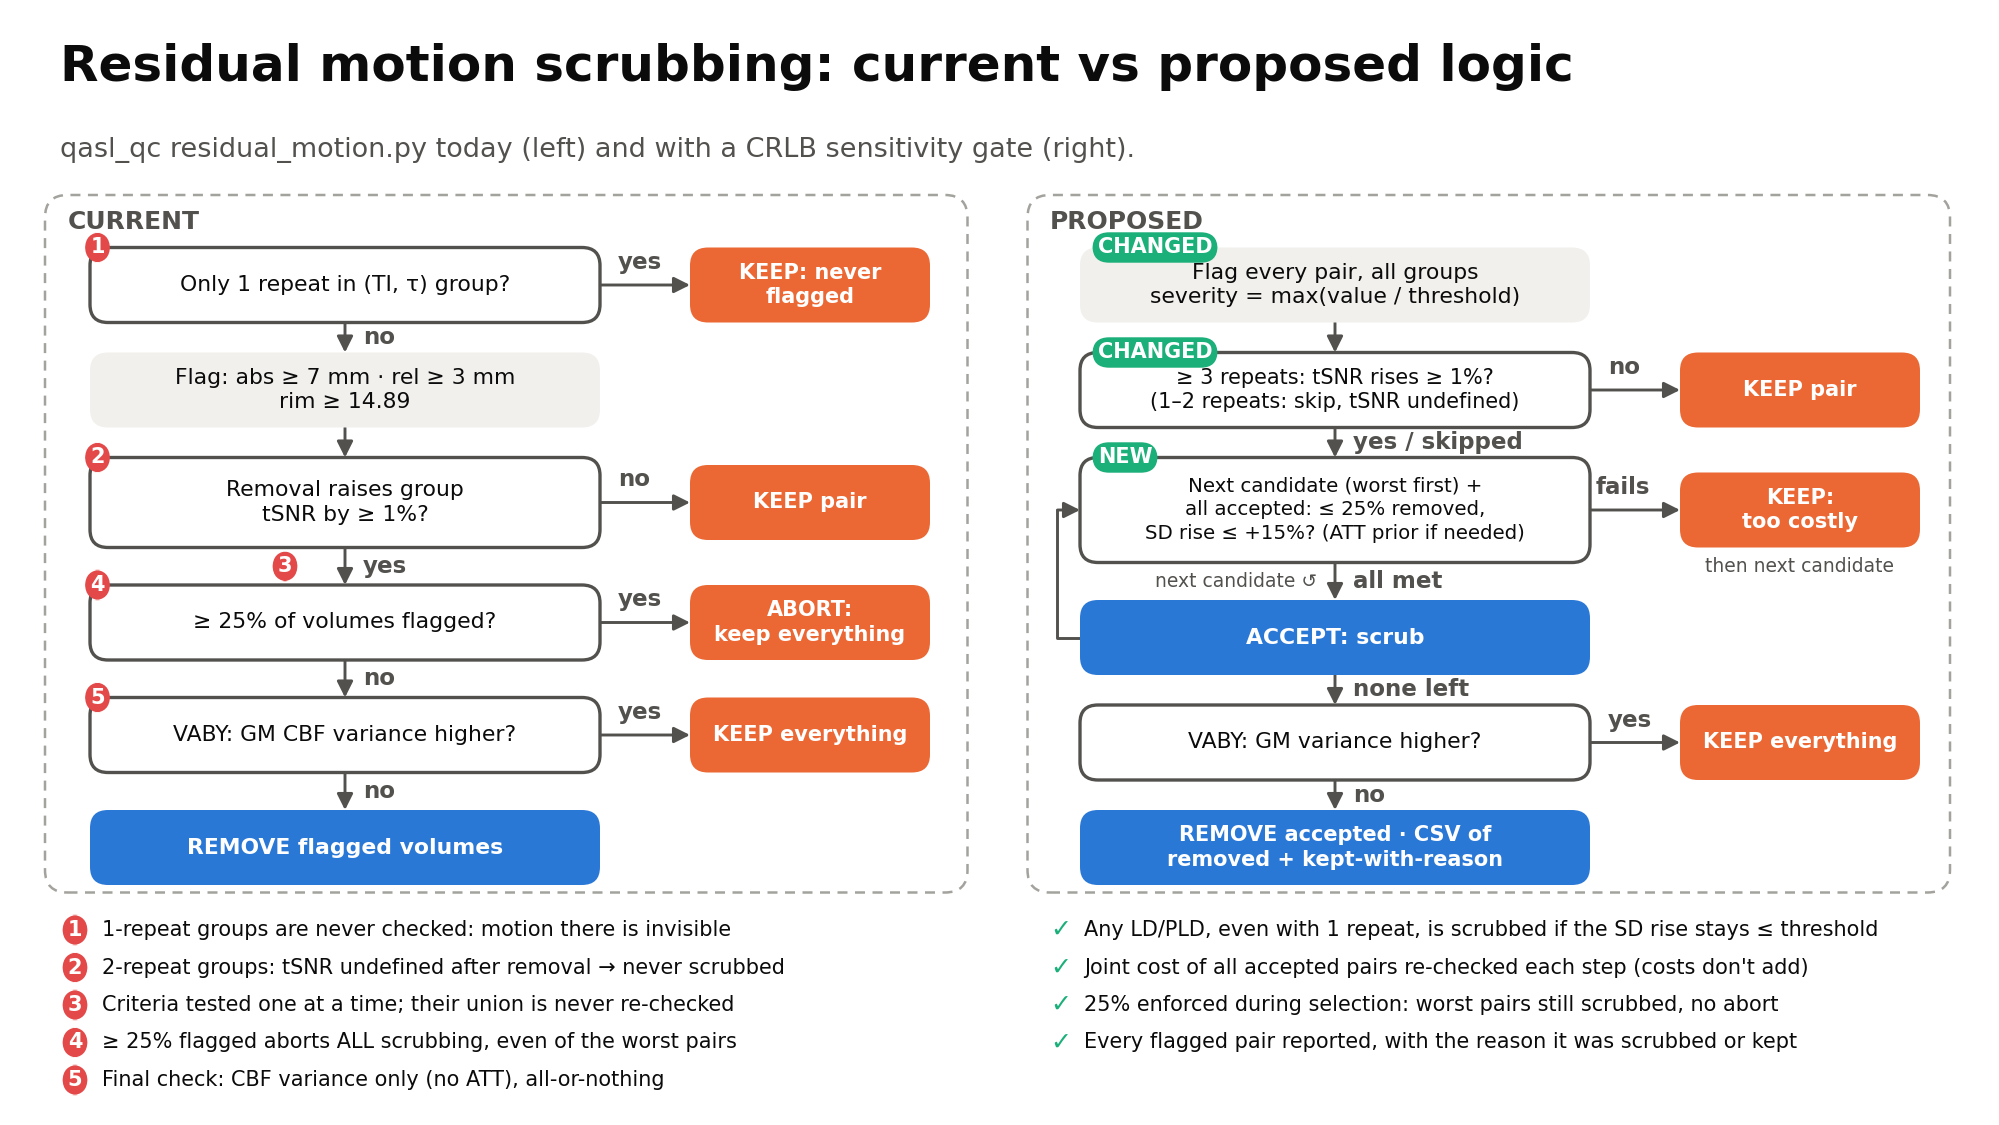

In [12]:
PROCESS_FC, DECISION_EC, PROBLEM, NEW = "#f1f0ed", INK2, "#e34948", AQUA


def flow_canvas(title, subtitle):
    """Full-slide axes in units of 0.1 inch (x 0-133, y 0-75)"""
    fig = plt.figure(figsize=SLIDE)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 133.3); ax.set_ylim(0, 75); ax.axis("off")
    ax.text(4, 70.5, title, fontsize=24, fontweight="bold", va="center", color=INK)
    ax.text(4, 65, subtitle, fontsize=13, va="center", color=INK2)
    return fig, ax


def node(ax, x, y, w, h, text, kind="process", fontsize=12):
    """Flowchart node centred at (x, y). kind: process, decision, keep, scrub, done"""
    style = {
        "process": dict(fc=PROCESS_FC, ec="none", lw=0, color=INK, weight="normal"),
        "decision": dict(fc="white", ec=DECISION_EC, lw=1.6, color=INK, weight="normal"),
        "keep": dict(fc=KEEP, ec="none", lw=0, color="white", weight="bold"),
        "scrub": dict(fc=SCRUB, ec="none", lw=0, color="white", weight="bold"),
        "done": dict(fc=CLEAN, ec="none", lw=0, color=INK, weight="normal"),
    }[kind]
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0,rounding_size=1.2",
                                fc=style["fc"], ec=style["ec"], lw=style["lw"], zorder=2))
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, color=style["color"],
            fontweight=style["weight"], zorder=3, linespacing=1.3)


def arrow(ax, start, end, label=None, label_pos=0.5, label_offset=(1.2, 0), connection="arc3"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=16, color=INK2, lw=1.4,
                                 connectionstyle=connection, shrinkA=0, shrinkB=0, zorder=1))
    if label:
        lx = start[0] + (end[0] - start[0]) * label_pos + label_offset[0]
        ly = start[1] + (end[1] - start[1]) * label_pos + label_offset[1]
        ax.text(lx, ly, label, fontsize=11, color=INK2, fontweight="bold", ha="left", va="center", zorder=3)


def elbow(ax, points, label=None, label_at=None, color=INK2):
    """Right-angled connector through the given points, with an arrowhead on the last segment"""
    xs, ys = zip(*points)
    ax.plot(xs[:-1], ys[:-1], color=color, lw=1.4, zorder=1, solid_capstyle="round")
    arrow(ax, points[-2], points[-1])
    if label:
        ax.text(*label_at, label, fontsize=11, color=INK2, fontweight="bold", ha="left", va="center", zorder=3)


def badge(ax, x, y, text, color):
    ax.text(x, y, text, ha="center", va="center", fontsize=10, color="white", fontweight="bold", zorder=4,
            bbox=dict(boxstyle="round,pad=0.25,rounding_size=0.8", fc=color, ec="none"))


def container(ax, x0, y0, x1, y1, label):
    ax.add_patch(FancyBboxPatch((x0, y0), x1 - x0, y1 - y0, boxstyle="round,pad=0,rounding_size=1.5",
                                fc="none", ec=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=0))
    ax.text(x0 + 1.5, y1 - 1.8, label, fontsize=12, color=INK2, fontweight="bold", va="center")


def fig_logic_comparison():
    fig, ax = flow_canvas("Residual motion scrubbing: current vs proposed logic",
                          "qasl_qc residual_motion.py today (left) and with a CRLB sensitivity gate (right).")
    fs = 10.5

    # ---- current (left)
    container(ax, 3, 15.5, 64.5, 62, "CURRENT")
    cx, ox, w, ow = 23, 54, 34, 16
    node(ax, cx, 56, w, 5, "Only 1 repeat in (TI, τ) group?", "decision", fs)
    node(ax, ox, 56, ow, 5, "KEEP: never\nflagged", "keep", 10)
    node(ax, cx, 49, w, 5, "Flag: abs ≥ 7 mm · rel ≥ 3 mm\nrim ≥ 14.89", fontsize=fs)
    node(ax, cx, 41.5, w, 6, "Removal raises group\ntSNR by ≥ 1%?", "decision", fs)
    node(ax, ox, 41.5, ow, 5, "KEEP pair", "keep", 10)
    node(ax, cx, 33.5, w, 5, "≥ 25% of volumes flagged?", "decision", fs)
    node(ax, ox, 33.5, ow, 5, "ABORT:\nkeep everything", "keep", 10)
    node(ax, cx, 26, w, 5, "VABY: GM CBF variance higher?", "decision", fs)
    node(ax, ox, 26, ow, 5, "KEEP everything", "keep", 10)
    node(ax, cx, 18.5, w, 5, "REMOVE flagged volumes", "scrub", fs)
    for y0, y1, lab in ((53.5, 51.5, "no"), (46.5, 44.5, None), (38.5, 36, "yes"), (31, 28.5, "no"),
                        (23.5, 21, "no")):
        arrow(ax, (cx, y0), (cx, y1), lab)
    for y, lab in ((56, "yes"), (41.5, "no"), (33.5, "yes"), (26, "yes")):
        arrow(ax, (cx + w / 2, y), (ox - ow / 2, y), lab, label_offset=(-1.8, 1.5))
    for n, y in (("1", 58.5), ("2", 44.5), ("4", 36), ("5", 28.5)):
        badge(ax, cx - w / 2 + 0.5, y, n, PROBLEM)
    badge(ax, cx - 4, 37.25, "3", PROBLEM)

    problems = [
        ("1", "1-repeat groups are never checked: motion there is invisible"),
        ("2", "2-repeat groups: tSNR undefined after removal → never scrubbed"),
        ("3", "Criteria tested one at a time; their union is never re-checked"),
        ("4", "≥ 25% flagged aborts ALL scrubbing, even of the worst pairs"),
        ("5", "Final check: CBF variance only (no ATT), all-or-nothing"),
    ]
    for i, (n, text) in enumerate(problems):
        y = 13 - i * 2.5
        badge(ax, 5, y, n, PROBLEM)
        ax.text(6.8, y, text, fontsize=10, va="center", color=INK)

    # ---- proposed (right)
    container(ax, 68.5, 15.5, 130, 62, "PROPOSED")
    cx, ox = 89, 120
    node(ax, cx, 56, w, 5, "Flag every pair, all groups\nseverity = max(value / threshold)", fontsize=fs)
    node(ax, cx, 49, w, 5, "≥ 3 repeats: tSNR rises ≥ 1%?\n(1–2 repeats: skip, tSNR undefined)", "decision", 10)
    node(ax, ox, 49, ow, 5, "KEEP pair", "keep", 10)
    node(ax, cx, 41, w, 7, "Next candidate (worst first) +\nall accepted: ≤ 25% removed,\nSD rise ≤ +15%? (ATT prior if needed)",
         "decision", 9.5)
    node(ax, ox, 41, ow, 5, "KEEP:\ntoo costly", "keep", 10)
    node(ax, cx, 32.5, w, 5, "ACCEPT: scrub", "scrub", fs)
    node(ax, cx, 25.5, w, 5, "VABY: GM variance higher?", "decision", fs)
    node(ax, ox, 25.5, ow, 5, "KEEP everything", "keep", 10)
    node(ax, cx, 18.5, w, 5, "REMOVE accepted · CSV of\nremoved + kept-with-reason", "scrub", 10)
    arrow(ax, (cx, 53.5), (cx, 51.5))
    arrow(ax, (cx, 46.5), (cx, 44.5), "yes / skipped")
    arrow(ax, (cx, 37.5), (cx, 35), "all met")
    arrow(ax, (cx, 30), (cx, 28), "none left")
    arrow(ax, (cx, 23), (cx, 21), "no")
    arrow(ax, (cx + w / 2, 49), (ox - ow / 2, 49), "no", label_offset=(-1.8, 1.5))
    arrow(ax, (cx + w / 2, 41), (ox - ow / 2, 41), "fails", label_offset=(-2.6, 1.5))
    arrow(ax, (cx + w / 2, 25.5), (ox - ow / 2, 25.5), "yes", label_offset=(-1.8, 1.5))
    # loop back to the gate for the next candidate
    elbow(ax, [(cx - w / 2, 32.5), (70.5, 32.5), (70.5, 41), (cx - w / 2, 41)])
    ax.text(cx - 1.2, 36.25, "next candidate ↺", fontsize=9, color=INK2, ha="right", va="center")
    ax.text(ox, 37.2, "then next candidate", fontsize=9, color=INK2, ha="center", va="center")
    badge(ax, cx - w / 2 + 5, 58.5, "CHANGED", NEW)
    badge(ax, cx - w / 2 + 5, 51.5, "CHANGED", NEW)
    badge(ax, cx - w / 2 + 3, 44.5, "NEW", NEW)

    gains = [
        "Any LD/PLD, even with 1 repeat, is scrubbed if the SD rise stays ≤ threshold",
        "Joint cost of all accepted pairs re-checked each step (costs don't add)",
        "25% enforced during selection: worst pairs still scrubbed, no abort",
        "Every flagged pair reported, with the reason it was scrubbed or kept",
    ]
    for i, text in enumerate(gains):
        y = 13 - i * 2.5
        ax.text(70, y, "✓", fontsize=12, color=NEW, fontweight="bold", va="center")
        ax.text(72.3, y, text, fontsize=10, va="center", color=INK)
    return save(fig, "10_logic_current_vs_proposed.png")


show(fig_logic_comparison())

## Tool: can I afford to remove these pairs?
`check_scrub(plds, lds, remove)` costs removing a specific set of label/control pairs and says whether it is affordable at the +15% SD threshold.

* **Protocol entry:** one LD/PLD per acquired L/C pair, in acquisition order, so every entry has an effective repeat of 1 (`lds` can be a single value if all LDs are equal). Pair indices (0-based) refer to positions in this list. If your protocol is written as delays with repeats, `unfold(plds, lds, repeats)` expands it to this form first.
* **remove:** pair indices to scrub. They are removed in the order given for the right-hand plot; the verdict depends only on the set.
* **Verdict:** affordable if the SD increase, averaged over ATT 0.5–2.5 s and CBF 10–100 ml/100g/min, is at most `threshold` for **both** CBF and ATT. Where a removal leaves part of that ATT range inestimable, the ATT prior (`ATT_PRIOR`) is used there and reported. The 25% data-loss limit is shown for information. If the set is not affordable, the tool reports the largest subset of your list that is, adding the cheapest pair at each step.
* **Returns** a dict with the SD increases, the verdict, and the affordable subset.

In [3]:
from oxasl_optpcasl.scrub import pair_delays


def unfold(plds, lds, repeats, order="interleaved"):
    """
    Expand a protocol given per delay (LD, PLD, number of repeats) into one entry per L/C pair

    :param order: 'interleaved' (all delays once per repeat) or 'blocked' (all repeats of a delay together);
                  must match the acquisition order so that pair indices are right
    :return: Tuple of per-pair PLDs and LDs (lists), in acquisition order
    """
    plds, lds, repeats = np.broadcast_arrays(np.asarray(plds, float), np.asarray(lds, float), np.asarray(repeats, int))
    delay = pair_delays(repeats, order)[0]
    return plds[delay].tolist(), lds[delay].tolist()


def check_scrub(plds, lds, remove, threshold=0.15, cbf_values=CBF_VALUES, att_prior=ATT_PRIOR, title="Protocol"):
    """
    Can these pairs be removed without raising CBF or ATT SD by more than the threshold?

    :param plds: PLD of each L/C pair in acquisition order (s)
    :param lds: LD of each pair (s), or a single value for all
    :param remove: 0-based indices of the pairs to remove
    :return: dict with the SD increases, verdict and the largest affordable subset of `remove`
    """
    plds = [float(v) for v in plds]
    lds = [float(v) for v in np.broadcast_to(np.asarray(lds, float), len(plds))]
    remove = [int(i) for i in remove]
    npairs = len(plds)
    if len(set(remove)) != len(remove) or any(not 0 <= i < npairs for i in remove):
        raise ValueError(f"remove must be distinct pair indices between 0 and {npairs - 1}")

    u_lds, u_plds, repeats, delay_of_pair = group_pairs(plds, lds)
    sa = ScrubbingAnalysis(u_lds, u_plds, repeats, delay_of_pair=delay_of_pair, cbf_values=cbf_values,
                           att_prior=att_prior)
    counts = sa.counts(remove)
    inc = {m: float(sa.sd_increase(counts, m)) for m in ("CBF", "ATT")}
    affordable = all(np.isfinite(v) and v <= threshold for v in inc.values())
    loss = len(remove) / npairs
    prior = prior_note(sa, counts)

    # Largest affordable subset of the requested pairs, adding the cheapest at each step
    subset, remaining = [], list(remove)
    while remaining:
        trials = np.array([sa.counts(subset + [r]) for r in remaining])
        worst = np.maximum(sa.sd_increase(trials, "CBF"), sa.sd_increase(trials, "ATT"))
        best = int(np.nanargmin(np.where(np.isfinite(worst), worst, np.inf)))
        if not (np.isfinite(worst[best]) and worst[best] <= threshold):
            break
        subset.append(remaining.pop(best))

    # ---- figure: SD increase across ATT, and as the listed pairs are removed one by one
    fig, (ax, axc) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.15]})
    atts = sa.att_dist.atts
    used = sa.prior_atts(counts)
    if used.any():
        ax.axvspan(atts[used].min(), atts[used].max(), color=LIGHT, lw=0, label="ATT prior used")
    for m, color in (("CBF", BLUE), ("ATT", ORANGE)):
        ax.plot(atts, 100 * sa.sd_increase_by_att(counts, m), color=color, label=f"{m} ({inc[m]:+.1%} averaged)")
    ax.axhline(100 * threshold, color=INK, ls="--", lw=1.2)
    ax.text(0.99, 100 * threshold, f"threshold +{threshold:.0%}", transform=ax.get_yaxis_transform(),
            ha="right", va="bottom", fontsize=11)
    ax.set_xlabel("ATT (s)"); ax.set_ylabel("SD increase (%)")
    ax.set_ylim(0, max(2 * 100 * threshold, 1.15 * np.nanmax([100 * sa.sd_increase_by_att(counts, m) for m in ("CBF", "ATT")])))
    ax.set_title("SD increase at each ATT (CBF-averaged)", loc="left", fontsize=14)
    ax.legend(loc="upper right", fontsize=10)

    steps = sa.progressive_counts(remove)
    ks = np.arange(len(steps))
    for m, color in (("CBF", BLUE), ("ATT", ORANGE)):
        axc.plot(ks, 100 * sa.sd_increase(steps, m), color=color, marker="o", label=m)
    axc.axhline(100 * threshold, color=INK, ls="--", lw=1.2)
    axc.text(0.99, 100 * threshold, f"threshold +{threshold:.0%}", transform=axc.get_yaxis_transform(),
             ha="right", va="bottom", fontsize=11)
    labels = ["none"] + [f"#{i}\n{lds[i]:g}/{plds[i]:g}" for i in remove]
    axc.set_xticks(ks, labels, fontsize=10)
    axc.set_xlabel("pair removed (index, LD/PLD s), cumulative"); axc.set_ylabel("SD increase (%)")
    axc.set_title("SD increase as the listed pairs are removed in turn", loc="left", fontsize=14)
    axc.legend(loc="upper left", fontsize=10); axc.grid(axis="x", visible=False)
    verdict = "AFFORDABLE" if affordable else "NOT AFFORDABLE"
    fig.suptitle(f"{title}: remove {len(remove)} of {npairs} pairs ({loss:.0%}) → {verdict}   "
                 f"(CBF {inc['CBF']:+.1%}, ATT {inc['ATT']:+.1%}; threshold +{threshold:.0%})",
                 x=0.01, ha="left", fontsize=15, fontweight="bold")
    plt.tight_layout(); plt.show()

    # ---- text report
    singles = {i: (sa.sd_increase(sa.counts([i]), "CBF"), sa.sd_increase(sa.counts([i]), "ATT")) for i in remove}
    table = pd.DataFrame({"LD (s)": lds, "PLD (s)": plds, "TI (s)": np.round(np.add(lds, plds), 3),
                          "remove": ["yes" if i in remove else "" for i in range(npairs)],
                          "CBF +% alone": [f"{100 * singles[i][0]:+.1f}" if i in remove else "" for i in range(npairs)],
                          "ATT +% alone": [f"{100 * singles[i][1]:+.1f}" if i in remove else "" for i in range(npairs)]})
    table.index.name = "pair"
    display(table)
    print(f"{verdict}: removing pairs {remove} raises CBF SD by {inc['CBF']:+.1%} and ATT SD by {inc['ATT']:+.1%} "
          f"(threshold +{threshold:.0%}).")
    print(f"Data removed: {loss:.0%} ({'within' if loss <= MAX_LOSS + 1e-9 else 'BEYOND'} the {MAX_LOSS:.0%} limit).")
    if prior:
        print(f"Note: ATT prior ({att_prior[0]:g} ± {att_prior[1]:g} s) used for {prior.replace('prior for ', '')}; "
              "ATT there is mostly set by the prior.")
    if not affordable:
        if subset:
            sub_counts = sa.counts(subset)
            print(f"Largest affordable subset of your list (cheapest first): {sorted(subset)} "
                  f"(CBF {sa.sd_increase(sub_counts, 'CBF'):+.1%}, ATT {sa.sd_increase(sub_counts, 'ATT'):+.1%}); "
                  f"keep {sorted(set(remove) - set(subset))}.")
        else:
            print("None of the listed pairs can be removed on its own within the threshold.")
    return {"CBF": inc["CBF"], "ATT": inc["ATT"], "affordable": affordable, "data_removed": loss,
            "affordable_subset": sorted(subset), "prior_used": prior or None}

### Example 1: 16-pair protocol (one repeat per LD/PLD), remove pairs 3, 10 and 12

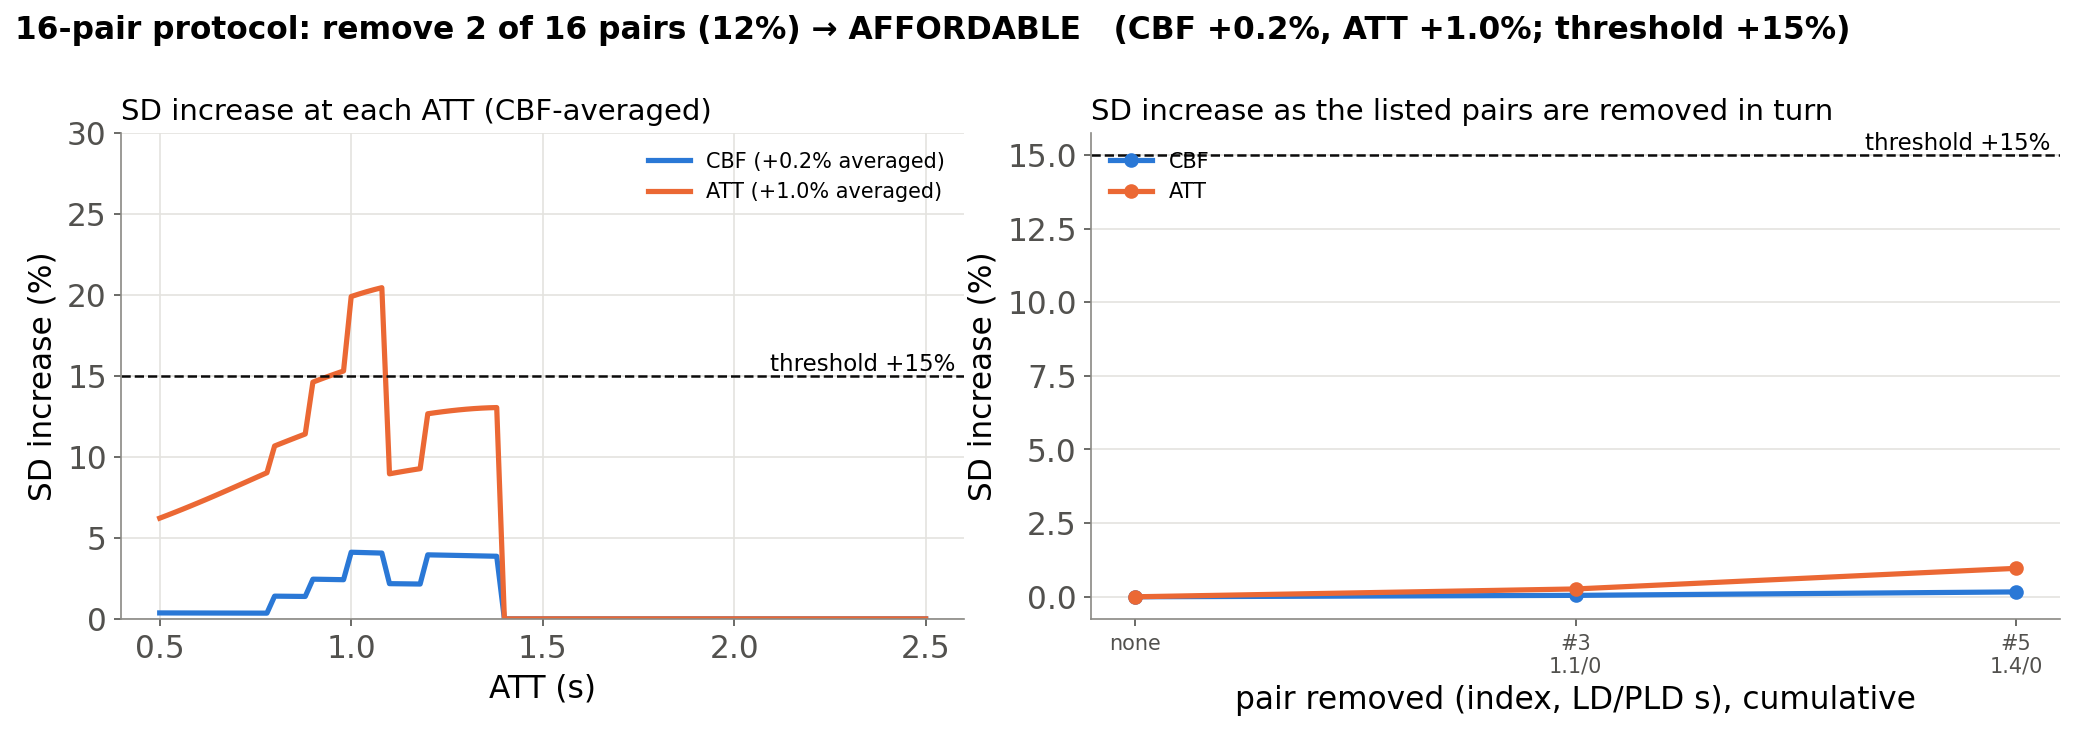

,LD (s),PLD (s),TI (s),remove,CBF +% alone,ATT +% alone
pair,,,,,,
0,0.8,0.0,0.8,,,
1,0.9,0.0,0.9,,,
2,1.0,0.0,1.0,,,
3,1.1,0.0,1.1,yes,+0.0,+0.3
4,1.2,0.0,1.2,,,
5,1.4,0.0,1.4,yes,+0.1,+0.6
6,1.6,0.0,1.6,,,
7,1.8,0.0,1.8,,,
8,1.8,0.2,2.0,,,


AFFORDABLE: removing pairs [3, 5] raises CBF SD by +0.2% and ATT SD by +1.0% (threshold +15%).
Data removed: 12% (within the 25% limit).


In [8]:
PLDS_16 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.5, 0.8, 1.1, 1.4, 1.7, 2.0, 2.2]
LDS_16 = [0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8]
result = check_scrub(PLDS_16, LDS_16, remove=[3, 5], title="16-pair protocol")

### Example 2: 5-PLD protocol with 2 repeats, entered per delay and unfolded
`unfold` lists every L/C pair in acquisition order (here interleaved: all 5 PLDs, then all 5 again), so pairs 0 and 5 are the two PLD 1.025 s repeats.

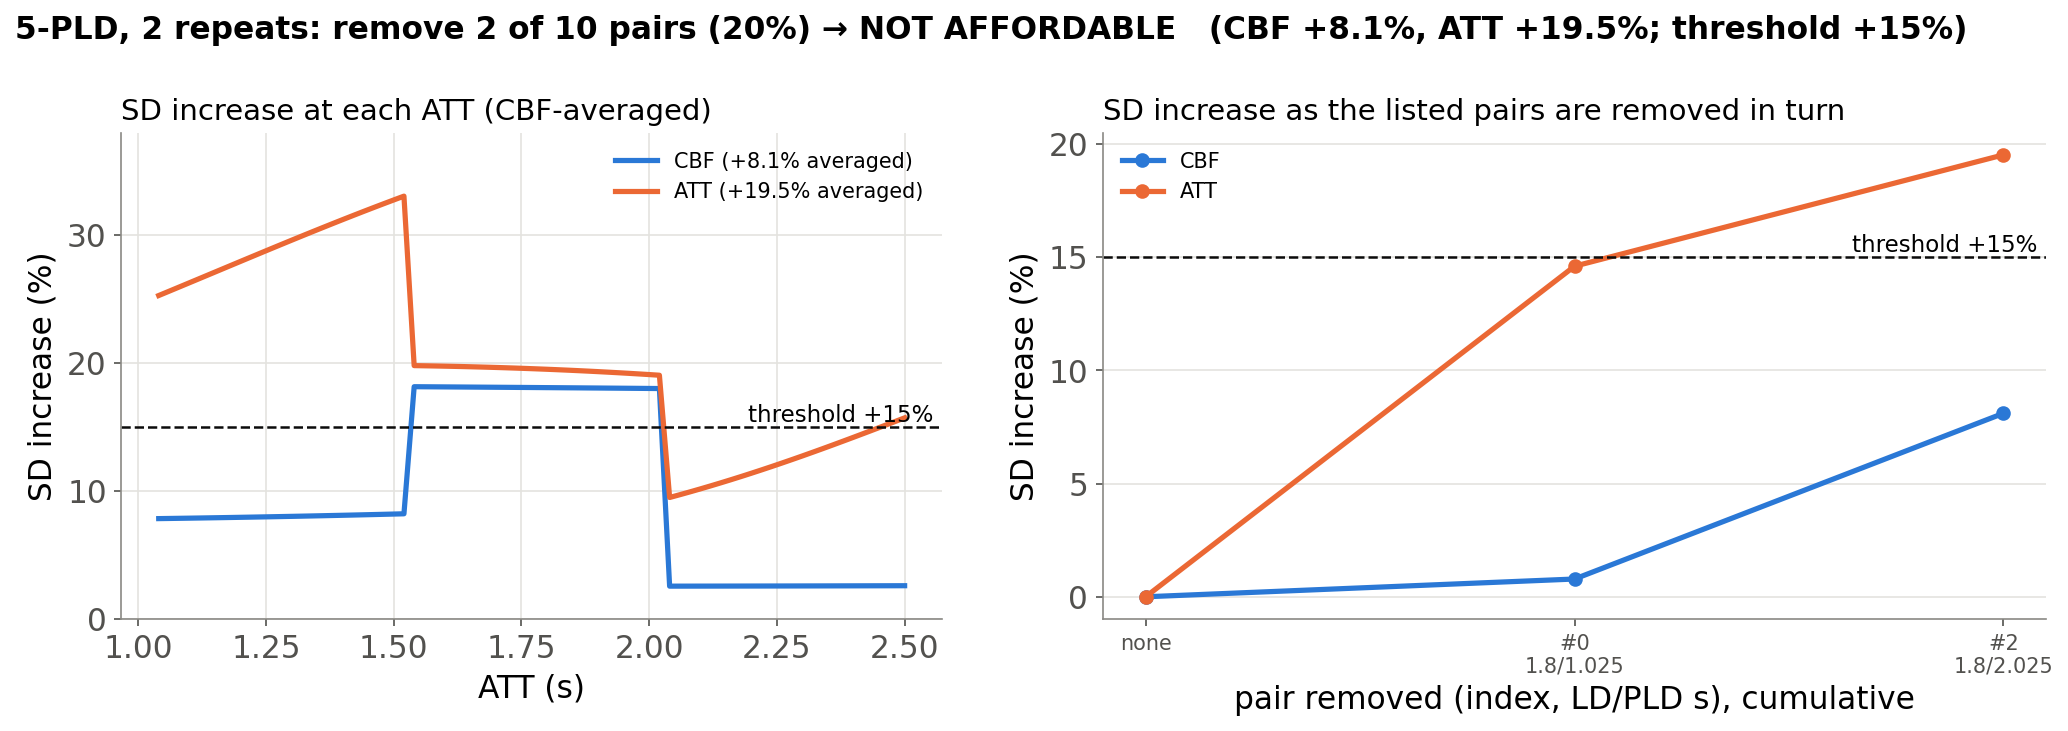

,LD (s),PLD (s),TI (s),remove,CBF +% alone,ATT +% alone
pair,,,,,,
0,1.8,1.025,2.825,yes,+0.8,+14.6
1,1.8,1.525,3.325,,,
2,1.8,2.025,3.825,yes,+7.6,+4.6
3,1.8,2.525,4.325,,,
4,1.8,3.025,4.825,,,
5,1.8,1.025,2.825,,,
6,1.8,1.525,3.325,,,
7,1.8,2.025,3.825,,,
8,1.8,2.525,4.325,,,


NOT AFFORDABLE: removing pairs [0, 2] raises CBF SD by +8.1% and ATT SD by +19.5% (threshold +15%).
Data removed: 20% (within the 25% limit).
Largest affordable subset of your list (cheapest first): [2] (CBF +7.6%, ATT +4.6%); keep [0].


In [9]:
plds_5x2, lds_5x2 = unfold([1.025, 1.525, 2.025, 2.525, 3.025], 1.8, repeats=2)
result = check_scrub(plds_5x2, lds_5x2, remove=[0, 2], title="5-PLD, 2 repeats")